In [129]:
!pip install -q ucimlrepo

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve
)
import joblib
import sklearn

In [131]:
pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

Pandas version: 2.2.2
NumPy version: 2.0.2
Scikit-learn version: 1.6.1


In [132]:
dataset = fetch_ucirepo(id=563)
X = dataset.data.features.copy()
y = dataset.data.targets.copy()
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Metadata",dataset.metadata)
display(dataset.variables)

Feature shape: (3150, 13)
Target shape: (3150, 1)
Metadata {'uci_id': 563, 'name': 'Iranian Churn', 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv', 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.", 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 3150, 'num_features': 13, 'feature_types': ['Integer'], 'demographics': ['Age'], 'target_col': ['Churn'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Sat Mar 09 2024', 'dataset_doi': '10.24432/C5JW3Z', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representi

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


In [133]:
print(y.head())
print(y.columns)

   Churn
0      0
1      0
2      0
3      0
4      0
Index(['Churn'], dtype='object')


In [134]:
y = y.squeeze()
print(y.head())
print(y.name)
print(type(y))

0    0
1    0
2    0
3    0
4    0
Name: Churn, dtype: int64
Churn
<class 'pandas.core.series.Series'>


In [135]:
df = X.copy()
df["Churn"] = y
display(df.head())

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [136]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Number of input features:", X.shape[1])
print("Display Colum names : ",df.columns.tolist())


Number of rows: 3150
Number of columns: 14
Number of input features: 13
Display Colum names :  ['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value', 'Churn']


In [137]:
#EDA
#Data-quality checks
#Checking missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values.to_frame(name="Missing Values"))
missing_summary = pd.DataFrame({
    "Missing Values" : df.isnull().sum(),
    "Missing Percentage" :  (df.isnull().sum().mean()*100).round(2)
})
display(missing_summary)
print("Total missing values:", df.isnull().sum().sum())


,Missing Values
Call Failure,0
Complains,0
Subscription Length,0
Charge Amount,0
Seconds of Use,0
Frequency of use,0
Frequency of SMS,0
Distinct Called Numbers,0
Age Group,0
Tariff Plan,0


,Missing Values,Missing Percentage
Call Failure,0,0.0
Complains,0,0.0
Subscription Length,0,0.0
Charge Amount,0,0.0
Seconds of Use,0,0.0
Frequency of use,0,0.0
Frequency of SMS,0,0.0
Distinct Called Numbers,0,0.0
Age Group,0,0.0
Tariff Plan,0,0.0


Total missing values: 0


In [138]:
#Checking Duplicate Rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows : ", duplicate_count)
duplicate_rows = df[df.duplicated(keep=False)]
display(duplicate_rows.head(10))

Number of duplicate rows :  300


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0
5,11,0,38,1,3775,82,32,28,3,1,1,30,282.280,0
6,4,0,38,0,2360,39,285,18,3,1,1,30,1235.960,0
7,13,0,37,2,9115,121,144,43,3,1,1,30,945.440,0
8,7,0,38,0,13773,169,0,44,3,1,1,30,557.680,0
9,7,0,38,1,4515,83,2,25,3,1,1,30,191.920,0


In [139]:
#Generate descriptive statistics
display(df.describe().T)
summary_statistics = df.describe().T[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

display(summary_statistics.round(2))

,count,mean,std,min,25%,50%,75%,max
Call Failure,3150.0,7.627937,7.263886,0.0,1.00000,6.00,12.00000,36.00
Complains,3150.0,0.076508,0.265851,0.0,0.00000,0.00,0.00000,1.00
Subscription Length,3150.0,32.541905,8.573482,3.0,30.00000,35.00,38.00000,47.00
Charge Amount,3150.0,0.942857,1.521072,0.0,0.00000,0.00,1.00000,10.00
Seconds of Use,3150.0,4472.459683,4197.908687,0.0,1391.25000,2990.00,6478.25000,17090.00
Frequency of use,3150.0,69.460635,57.413308,0.0,27.00000,54.00,95.00000,255.00
Frequency of SMS,3150.0,73.174921,112.237560,0.0,6.00000,21.00,87.00000,522.00
Distinct Called Numbers,3150.0,23.509841,17.217337,0.0,10.00000,21.00,34.00000,97.00
Age Group,3150.0,2.826032,0.892555,1.0,2.00000,3.00,3.00000,5.00
Tariff Plan,3150.0,1.077778,0.267864,1.0,1.00000,1.00,1.00000,2.00


,count,mean,std,min,25%,50%,75%,max
Call Failure,3150.0,7.63,7.26,0.0,1.00,6.00,12.00,36.00
Complains,3150.0,0.08,0.27,0.0,0.00,0.00,0.00,1.00
Subscription Length,3150.0,32.54,8.57,3.0,30.00,35.00,38.00,47.00
Charge Amount,3150.0,0.94,1.52,0.0,0.00,0.00,1.00,10.00
Seconds of Use,3150.0,4472.46,4197.91,0.0,1391.25,2990.00,6478.25,17090.00
Frequency of use,3150.0,69.46,57.41,0.0,27.00,54.00,95.00,255.00
Frequency of SMS,3150.0,73.17,112.24,0.0,6.00,21.00,87.00,522.00
Distinct Called Numbers,3150.0,23.51,17.22,0.0,10.00,21.00,34.00,97.00
Age Group,3150.0,2.83,0.89,1.0,2.00,3.00,3.00,5.00
Tariff Plan,3150.0,1.08,0.27,1.0,1.00,1.00,1.00,2.00


In [140]:
#Checking Unique Values
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Number of Unique Values": [
        df[column].nunique() for column in df.columns
    ]
})

display(unique_values)

,Column,Number of Unique Values
0,Call Failure,37
1,Complains,2
2,Subscription Length,45
3,Charge Amount,11
4,Seconds of Use,1756
5,Frequency of use,242
6,Frequency of SMS,405
7,Distinct Called Numbers,92
8,Age Group,5
9,Tariff Plan,2


In [141]:
for column in df.columns:
    if df[column].nunique() <= 10:
        print(f"\nColumn: {column}")
        print(df[column].value_counts().sort_index())


Column: Complains
Complains
0    2909
1     241
Name: count, dtype: int64

Column: Age Group
Age Group
1     123
2    1037
3    1425
4     395
5     170
Name: count, dtype: int64

Column: Tariff Plan
Tariff Plan
1    2905
2     245
Name: count, dtype: int64

Column: Status
Status
1    2368
2     782
Name: count, dtype: int64

Column: Age
Age
15     123
25    1037
30    1425
45     395
55     170
Name: count, dtype: int64

Column: Churn
Churn
0    2655
1     495
Name: count, dtype: int64


In [142]:
#Target-class analysis
#Checking the class distribution
class_counts = df["Churn"].value_counts().sort_index()


class_percentages = (
    df["Churn"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
class_distribution  = pd.DataFrame({
    "Customer Count": class_counts,
    "Percentage": class_percentages
})
class_distribution.index = [
    "No Churn",
    "Churn"
]
display(class_distribution)


,Customer Count,Percentage
No Churn,2655,84.29
Churn,495,15.71


[<BarContainer object of 1 artists>, <BarContainer object of 1 artists>]


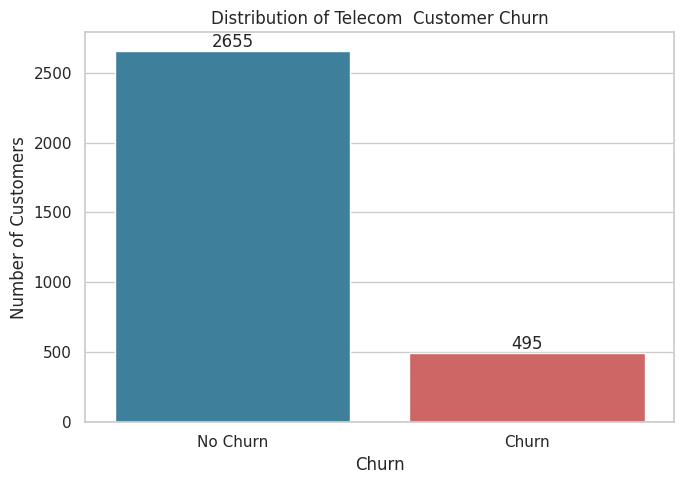

In [143]:
#Plot class distribution
plt.figure(figsize=(7,5))
ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette=["#2E86AB", "#E15554"],
    legend=False
)
print(ax.containers)
plt.title("Distribution of Telecom  Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No Churn", "Churn"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

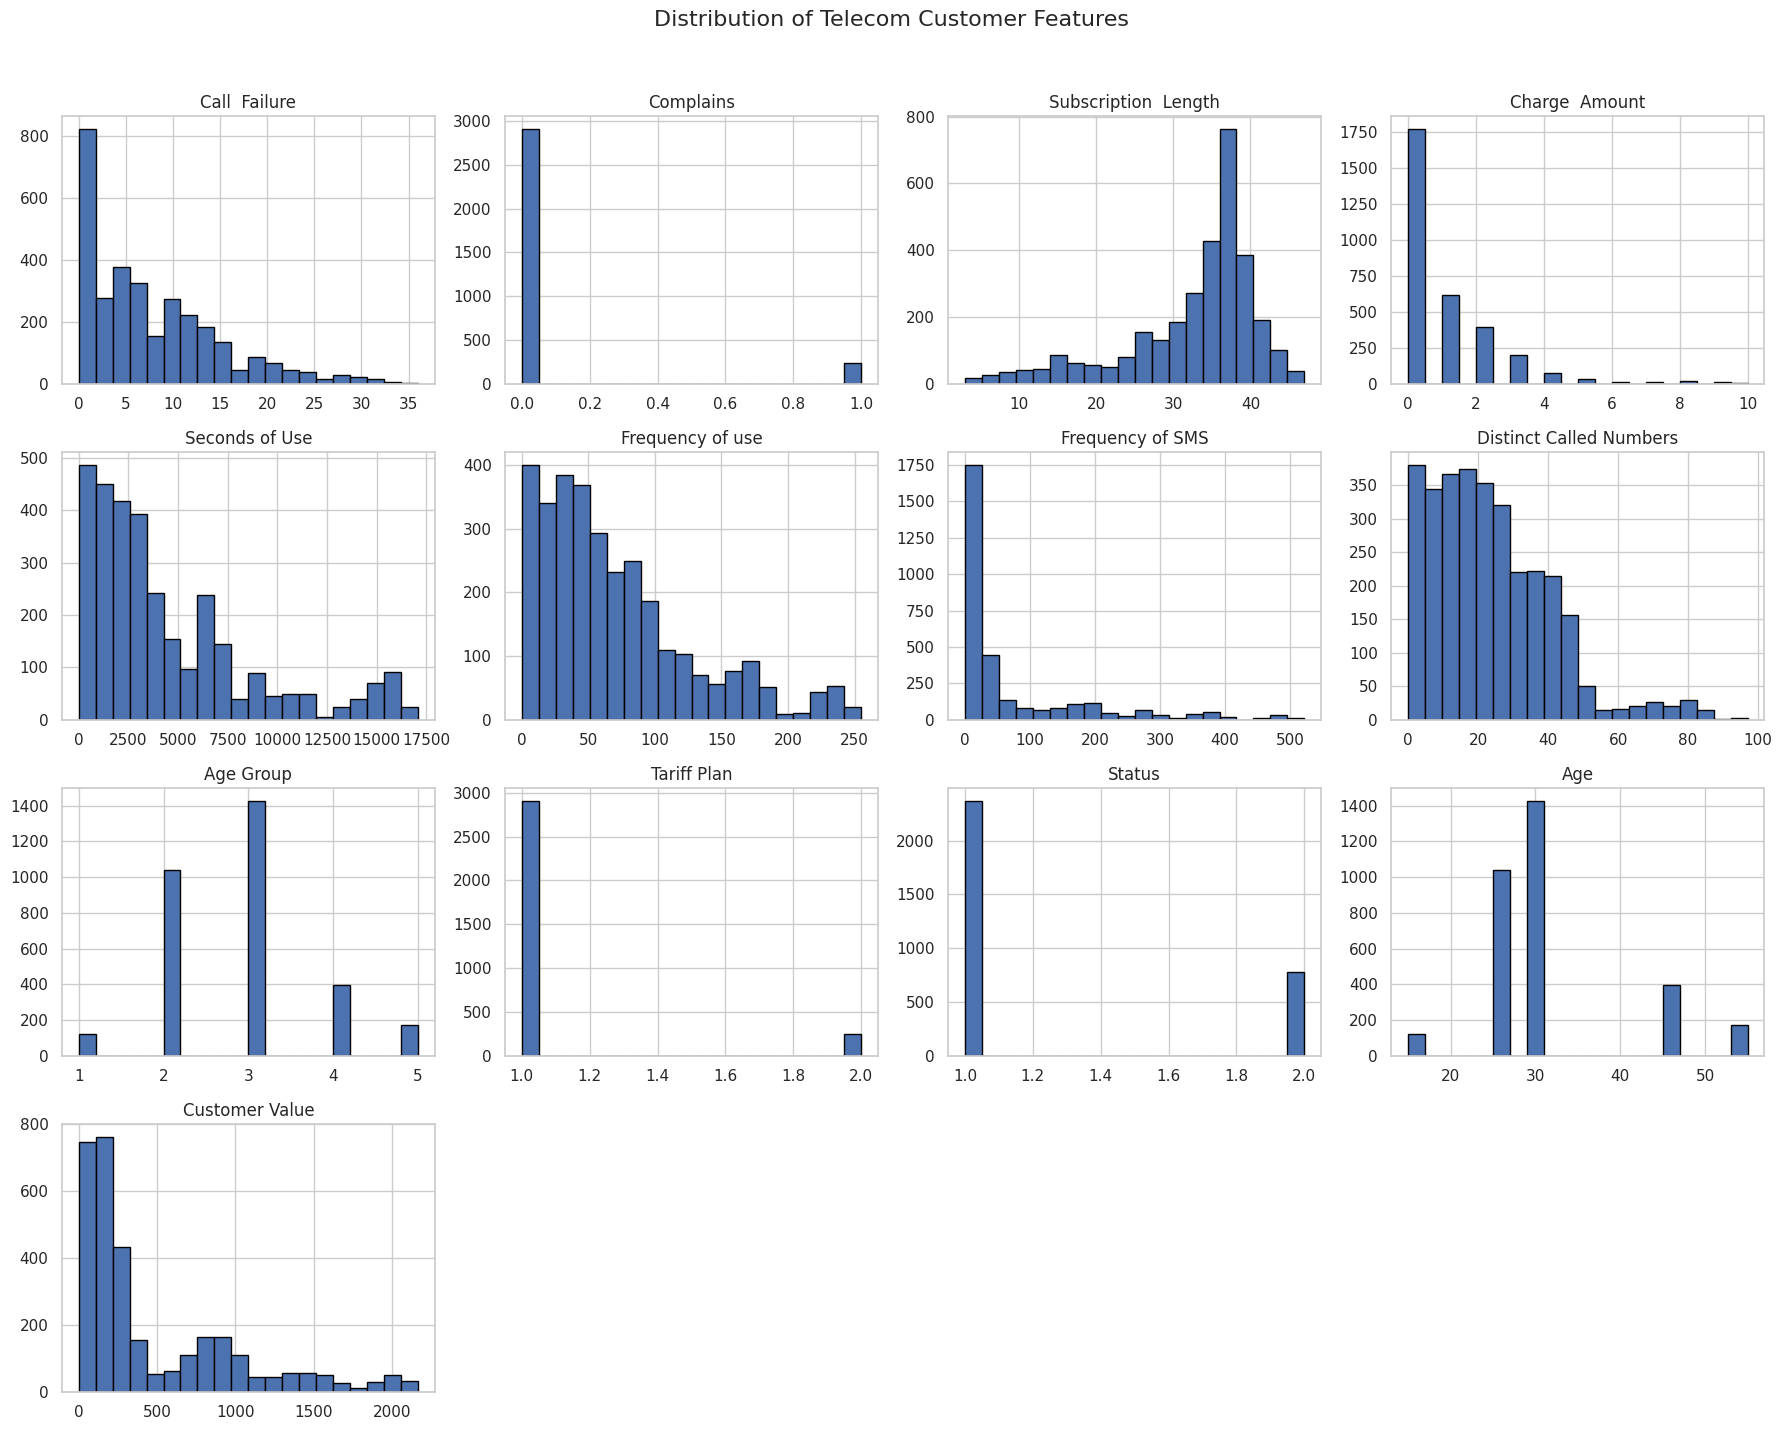

In [144]:
#Feature distributions
#Plot numerical-feature histograms
feature_columns = X.columns.tolist()
df[feature_columns].hist(
    figsize=(18, 14),
    bins=20,
    edgecolor="black"
)
plt.suptitle(
    "Distribution of Telecom Customer Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [145]:
print(df.columns.tolist())

['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value', 'Churn']


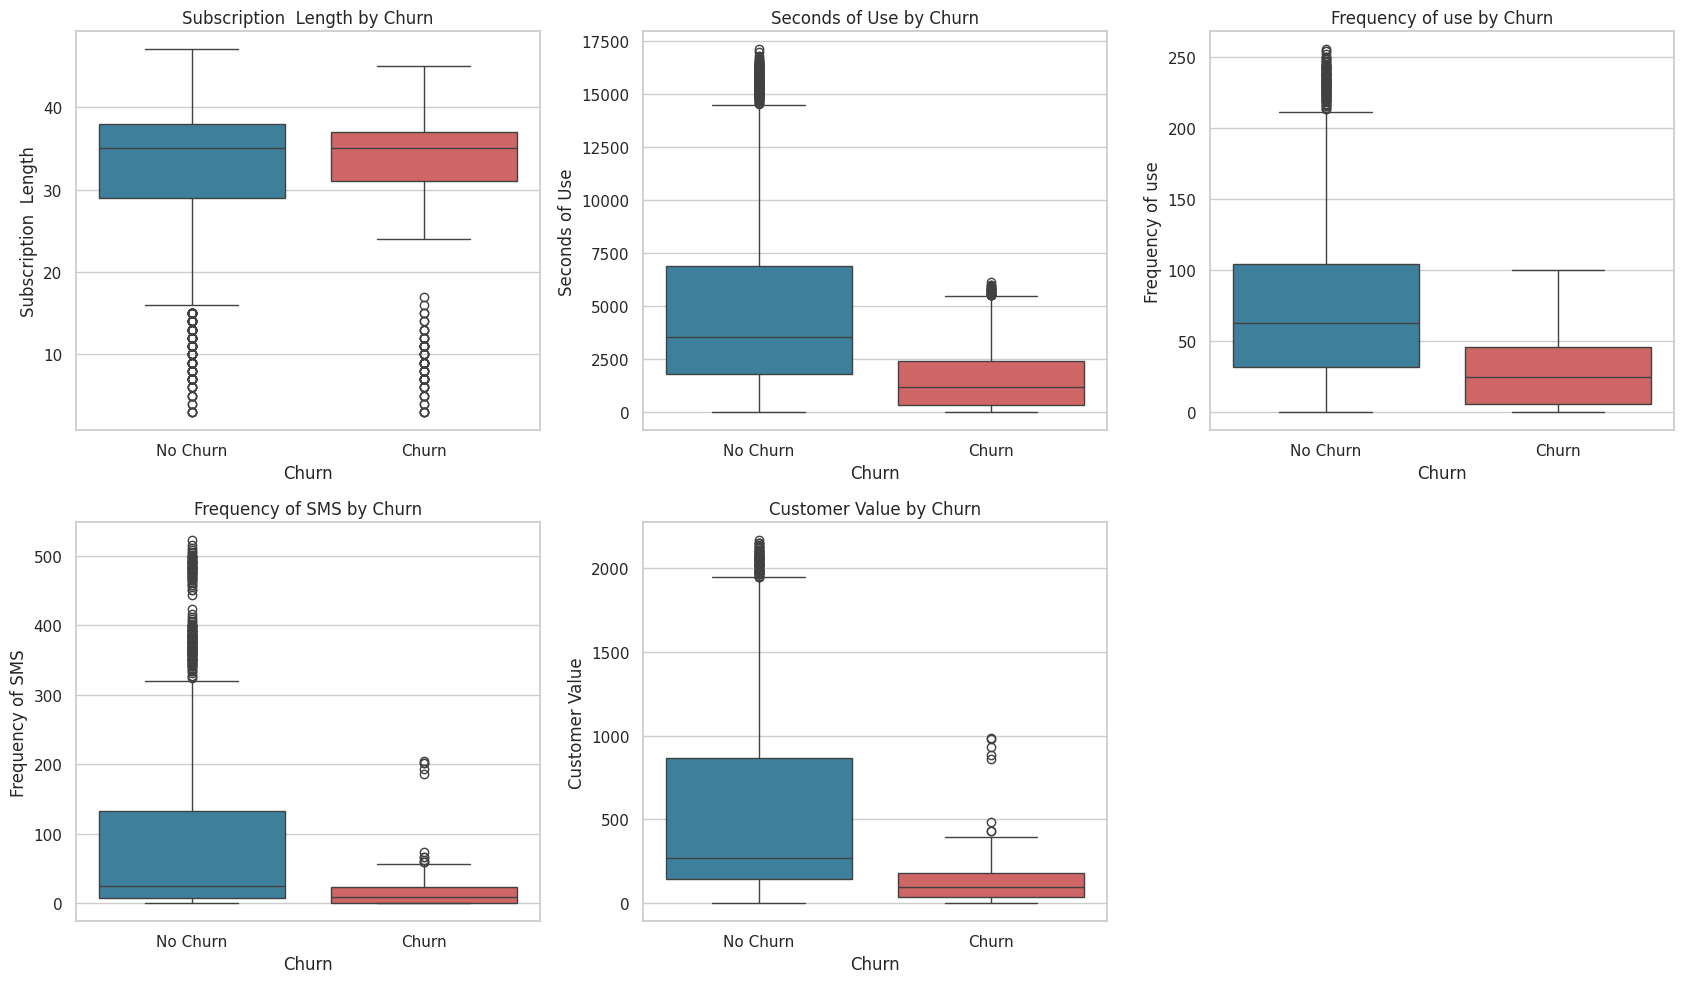

In [146]:
selected_features = [
    "Subscription  Length",
    "Seconds of Use",
    "Frequency of use",
    "Frequency of SMS",
    "Customer Value"
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(17, 10)
)

axes = axes.flatten()

for index, feature in enumerate(selected_features):
    sns.boxplot(
        data=df,
        x="Churn",
        y=feature,
        hue="Churn",
        palette=["#2E86AB", "#E15554"],
        legend=False,
        ax=axes[index]
    )

    axes[index].set_title(f"{feature} by Churn")
    axes[index].set_xticks([0, 1])
    axes[index].set_xticklabels(
        ["No Churn", "Churn"]
    )

axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [147]:
#Correlation analysis
#Calculate correlations
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
Call Failure,1.000000,0.152879,0.169737,0.589028,0.501607,0.573349,-0.022282,0.504058,0.050406,0.192285,-0.114645,0.041758,0.121225,-0.008987
Complains,0.152879,1.000000,-0.020286,-0.033948,-0.104952,-0.090774,-0.111633,-0.058199,0.019976,0.001140,0.271405,0.003298,-0.132895,0.532053
Subscription Length,0.169737,-0.020286,1.000000,0.078789,0.124618,0.106534,0.076318,0.092009,0.021453,-0.159680,0.142841,-0.002430,0.109565,-0.032588
Charge Amount,0.589028,-0.033948,0.078789,1.000000,0.446738,0.379096,0.091533,0.415198,0.279679,0.324232,-0.356269,0.278955,0.169428,-0.202305
Seconds of Use,0.501607,-0.104952,0.124618,0.446738,1.000000,0.946489,0.102123,0.676536,0.020060,0.133593,-0.460618,0.020843,0.415087,-0.298935
Frequency of use,0.573349,-0.090774,0.106534,0.379096,0.946489,1.000000,0.100019,0.736114,-0.032544,0.206452,-0.454752,-0.028350,0.401572,-0.303337
Frequency of SMS,-0.022282,-0.111633,0.076318,0.091533,0.102123,0.100019,1.000000,0.079650,-0.053719,0.195686,-0.296164,-0.092798,0.924877,-0.220754
Distinct Called Numbers,0.504058,-0.058199,0.092009,0.415198,0.676536,0.736114,0.079650,1.000000,0.020941,0.172079,-0.413039,0.051037,0.284807,-0.278867
Age Group,0.050406,0.019976,0.021453,0.279679,0.020060,-0.032544,-0.053719,0.020941,1.000000,-0.150593,0.002506,0.960758,-0.183481,-0.014550
Tariff Plan,0.192285,0.001140,-0.159680,0.324232,0.133593,0.206452,0.195686,0.172079,-0.150593,1.000000,-0.164143,-0.119426,0.252298,-0.105853


In [148]:
churn_correlations = (
    correlation_matrix["Churn"]
    .drop("Churn")
    .sort_values(ascending=False)
)

display(churn_correlations.to_frame(name="Correlation with Churn"))


,Correlation with Churn
Complains,0.532053
Status,0.498976
Call Failure,-0.008987
Age Group,-0.014550
Age,-0.017705
Subscription Length,-0.032588
Tariff Plan,-0.105853
Charge Amount,-0.202305
Frequency of SMS,-0.220754
Distinct Called Numbers,-0.278867


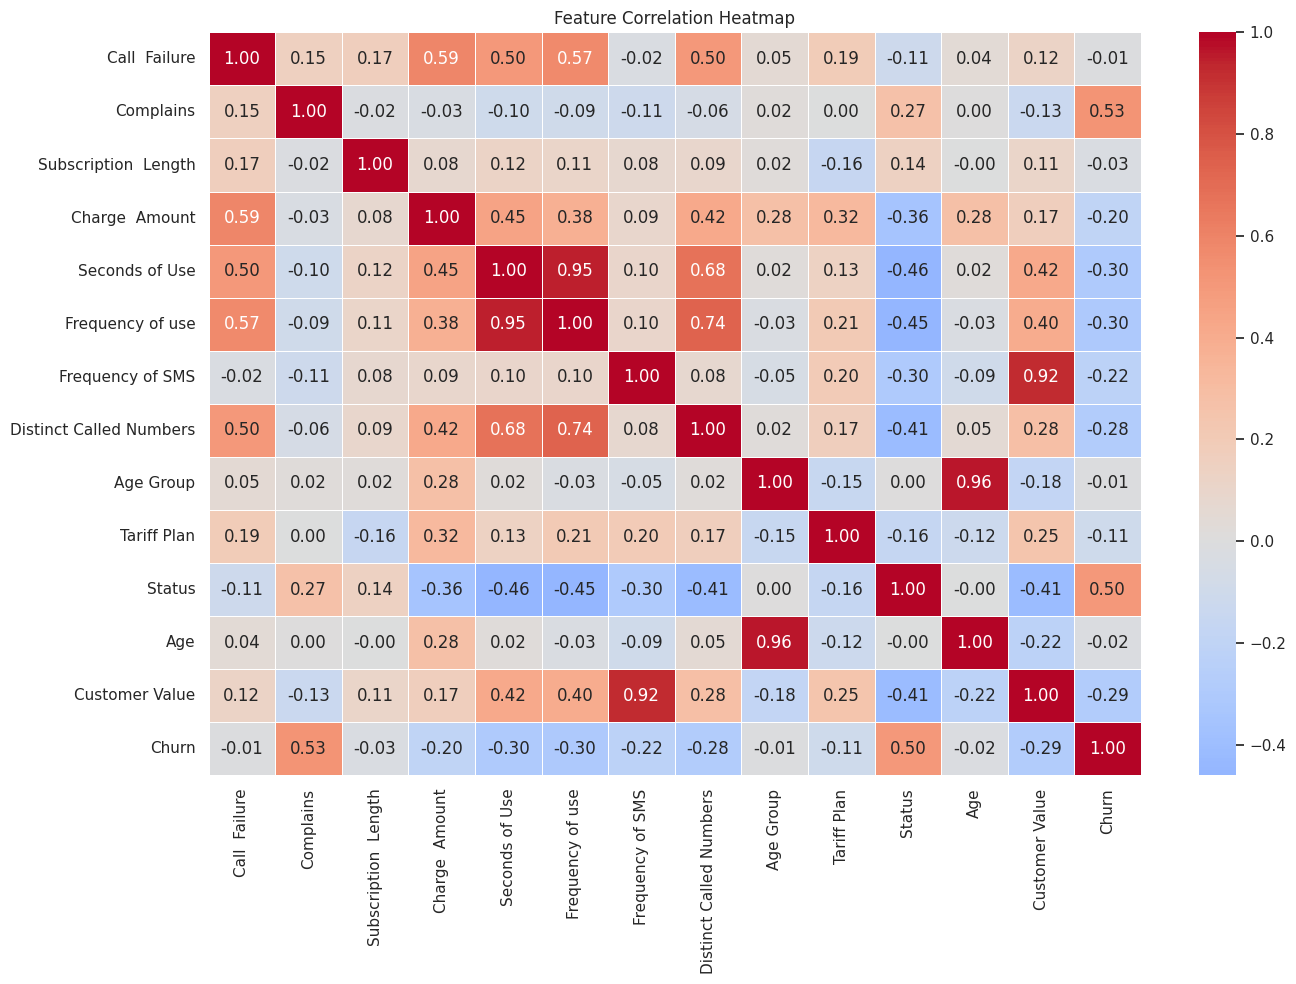

In [149]:
plt.figure(figsize=(14,10))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [150]:
X=df.drop(columns=["Churn"])
y=df["Churn"]
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts().sort_index())

X shape: (3150, 13)
y shape: (3150,)

Target values:
Churn
0    2655
1     495
Name: count, dtype: int64


In [151]:
#Split training and test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2520, 13)
X_test shape: (630, 13)
y_train shape: (2520,)
y_test shape: (630,)


In [152]:
#Verifying Stratification
split_distribution = pd.DataFrame({
    "Complete Dataset": y.value_counts(normalize=True).sort_index(),
    "Training Dataset": y_train.value_counts(normalize=True).sort_index(),
    "Testing Dataset": y_test.value_counts(normalize=True).sort_index()
}).mul(100).round(2)

split_distribution.index = [
    "No Churn (0)",
    "Churn (1)"
]

display(split_distribution)

,Complete Dataset,Training Dataset,Testing Dataset
No Churn (0),84.29,84.29,84.29
Churn (1),15.71,15.71,15.71


In [153]:
#Scaling
scaler_demo = StandardScaler()

X_train_scaled_demo = scaler_demo.fit_transform(X_train)
X_test_scaled_demo = scaler_demo.transform(X_test)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled_demo,
    columns=X_train.columns,
    index=X_train.index
)

display(X_train_scaled_df.head())

scaling_check = pd.DataFrame({
    "Scaled Mean": X_train_scaled_df.mean(),
    "Scaled Standard Deviation": X_train_scaled_df.std(ddof=0)
})

display(scaling_check.round(4))

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value
1675,-1.050888,-0.295202,-0.185454,-0.627292,-0.486113,-1.033970,-0.656742,-0.897157,0.193919,-0.291211,-0.573685,-0.114106,-0.723393
3053,1.011496,-0.295202,0.864493,0.034952,0.011837,0.045496,-0.585500,0.775698,-2.042583,-0.291211,-0.573685,-1.808884,-0.341077
1923,1.973941,-0.295202,0.281189,4.670662,1.526723,0.498175,-0.638931,0.948752,1.312170,-0.291211,-0.573685,1.580672,-0.374169
216,-1.050888,-0.295202,0.047868,-0.627292,-0.874576,-0.999148,-0.656742,-0.954841,-0.924332,-0.291211,1.743118,-0.679032,-0.840704
419,-0.913396,-0.295202,0.164529,-0.627292,0.687165,0.863800,2.664884,0.833383,-0.924332,-0.291211,-0.573685,-0.679032,2.969064


,Scaled Mean,Scaled Standard Deviation
Call Failure,-0.0,1.0
Complains,-0.0,1.0
Subscription Length,-0.0,1.0
Charge Amount,0.0,1.0
Seconds of Use,-0.0,1.0
Frequency of use,0.0,1.0
Frequency of SMS,0.0,1.0
Distinct Called Numbers,0.0,1.0
Age Group,-0.0,1.0
Tariff Plan,0.0,1.0


In [154]:
#Creating the pipeline
logistic_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])
logistic_pipeline.fit(X_train, y_train)
print("Logistic Regression training completed successfully.")

Logistic Regression training completed successfully.


In [155]:
#Make predictions
y_pred_logistic = logistic_pipeline.predict(X_test)
prediction_preview = pd.DataFrame({
    "Actual Churn": y_test.reset_index(drop=True),
    "Predicted Churn": y_pred_logistic
})

display(prediction_preview.head(20))


,Actual Churn,Predicted Churn
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,1,0
6,0,0
7,0,0
8,0,0
9,0,0


In [156]:
#Predict Probabilities
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]
prediction_preview["Churn Probability"] = y_prob_logistic

display(prediction_preview.head(20))

,Actual Churn,Predicted Churn,Churn Probability
0,0,0,0.126223
1,0,0,0.000828
2,0,0,0.025289
3,0,0,0.005719
4,0,0,0.002688
5,1,0,0.348978
6,0,0,0.023674
7,0,0,0.020578
8,0,0,0.013223
9,0,0,0.186819


In [157]:
#Calculate all required metrics
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_mcc = matthews_corrcoef(
    y_test,
    y_pred_logistic
)

logistic_results = pd.DataFrame({
    "ML Model Name": ["Logistic Regression"],
    "Accuracy": [logistic_accuracy],
    "AUC": [logistic_auc],
    "Precision": [logistic_precision],
    "Recall": [logistic_recall],
    "F1": [logistic_f1],
    "MCC": [logistic_mcc]
})

display(
    logistic_results.round(4)
)
print(f"Accuracy  : {logistic_accuracy:.4f}")
print(f"AUC       : {logistic_auc:.4f}")
print(f"Precision : {logistic_precision:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"F1 Score  : {logistic_f1:.4f}")
print(f"MCC Score : {logistic_mcc:.4f}")

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8968,0.9208,0.84,0.4242,0.5638,0.5509


Accuracy  : 0.8968
AUC       : 0.9208
Precision : 0.8400
Recall    : 0.4242
F1 Score  : 0.5638
MCC Score : 0.5509


[[523   8]
 [ 57  42]]


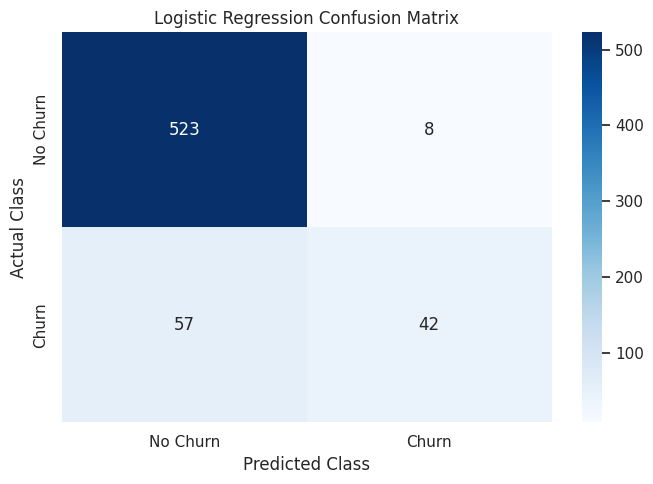

True Negatives : 523
False Positives: 8
False Negatives: 57
True Positives : 42


In [158]:
#Confusion matrix
logistic_cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(logistic_cm)

plt.figure(figsize=(7, 5))
sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = logistic_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

In [159]:
#Classification report
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)
logistic_report = classification_report(
    y_test,
    y_pred_logistic,
    target_names=["No Churn", "Churn"],
    output_dict=True,
    zero_division=0
)

logistic_report_df = pd.DataFrame(
    logistic_report
).transpose()

display(logistic_report_df.round(4))

              precision    recall  f1-score   support

    No Churn       0.90      0.98      0.94       531
       Churn       0.84      0.42      0.56        99

    accuracy                           0.90       630
   macro avg       0.87      0.70      0.75       630
weighted avg       0.89      0.90      0.88       630



,precision,recall,f1-score,support
No Churn,0.9017,0.9849,0.9415,531.0000
Churn,0.8400,0.4242,0.5638,99.0000
accuracy,0.8968,0.8968,0.8968,0.8968
macro avg,0.8709,0.7046,0.7526,630.0000
weighted avg,0.8920,0.8968,0.8821,630.0000


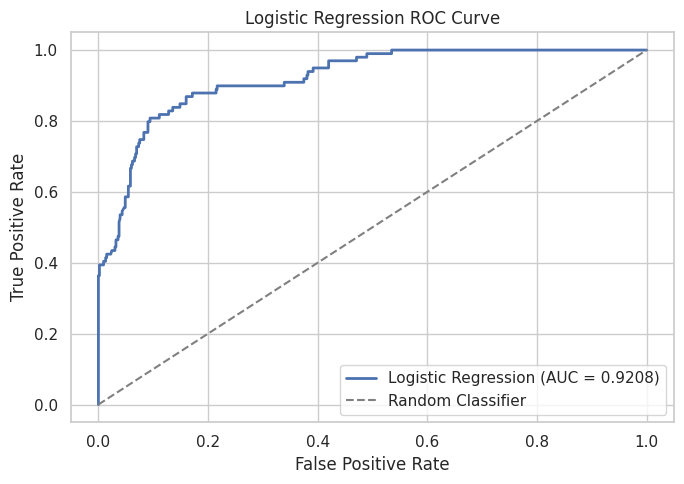

In [160]:
#ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_logistic
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {logistic_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


,Feature,Coefficient,Absolute Coefficient
5,Frequency of use,-2.1818,2.1818
6,Frequency of SMS,-1.3866,1.3866
1,Complains,1.0389,1.0389
0,Call Failure,0.8055,0.8055
4,Seconds of Use,0.7871,0.7871
3,Charge Amount,-0.6136,0.6136
10,Status,0.5412,0.5412
7,Distinct Called Numbers,-0.3083,0.3083
2,Subscription Length,-0.2837,0.2837
12,Customer Value,0.2054,0.2054


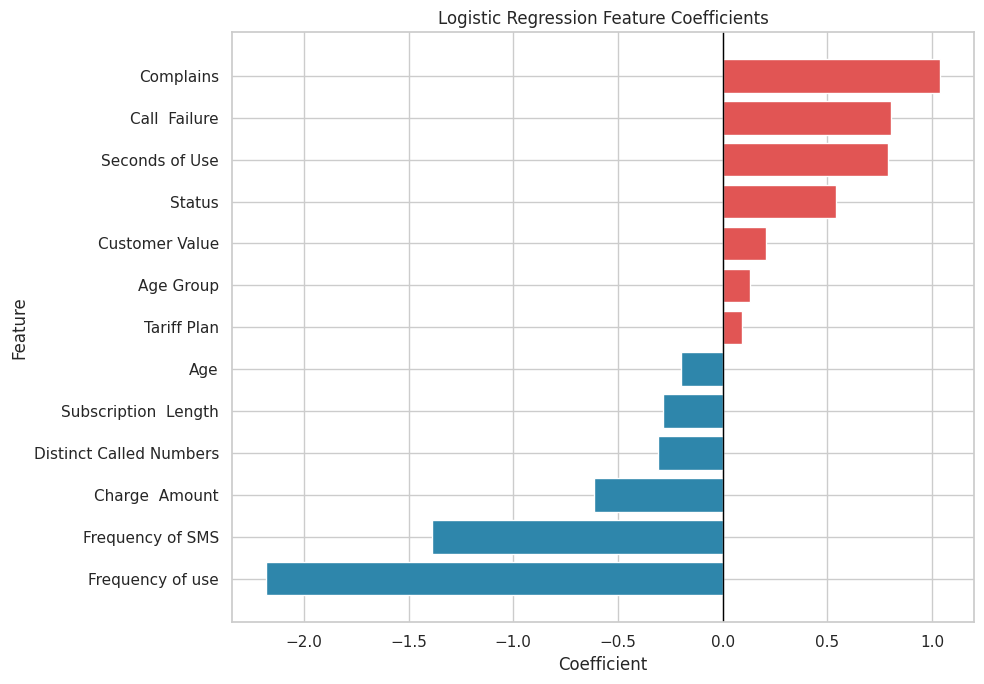

In [161]:
#Understand feature influence
trained_logistic_model = (
    logistic_pipeline.named_steps["classifier"]
)

coefficients = trained_logistic_model.coef_[0]
coefficient_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

coefficient_df["Absolute Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

display(coefficient_df.round(4))

plot_coefficients = coefficient_df.sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 7))

colors = [
    "#E15554" if value > 0 else "#2E86AB"
    for value in plot_coefficients["Coefficient"]
]

plt.barh(
    plot_coefficients["Feature"],
    plot_coefficients["Coefficient"],
    color=colors
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [162]:
#Test the saved model
loaded_logistic_pipeline = joblib.load(
    "model/logistic_regression.pkl"
)

loaded_predictions = loaded_logistic_pipeline.predict(
    X_test
)

print(
    "Saved model predictions match:",
    np.array_equal(
        y_pred_logistic,
        loaded_predictions
    )
)

Saved model predictions match: True


In [163]:
#Save metrics and test data
logistic_results.round(6).to_csv(
    "results/model_metrics.csv",
    index=False
)
test_data = X_test.copy()
test_data["Churn"] = y_test
display(test_data.head())

print("Test data shape:", test_data.shape)
test_data.to_csv(
    "test_data.csv",
    index=False
)
print("Saved files:")

for root, directories, files in os.walk("."):
    for file in files:
        if (
            file.endswith(".pkl")
            or file.endswith(".csv")
        ):
            print(os.path.join(root, file))

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
3036,2,0,36,0,1260,39,20,22,3,1,2,30,131.960,0
1783,18,0,29,2,15580,231,0,75,2,1,1,25,711.495,0
2539,7,0,25,1,1693,37,26,65,5,1,1,55,64.950,0
1807,6,0,30,0,8810,109,129,40,3,1,1,30,872.760,0
3020,6,0,38,1,11060,149,0,49,4,1,1,45,280.225,0


Test data shape: (630, 14)
Saved files:
./test_data.csv
./results/model_ranking.csv
./results/best_models_by_metric.csv
./results/model_metrics.csv
./model/knn.pkl
./model/decision_tree.pkl
./model/random_forest.pkl
./model/naive_bayes.pkl
./model/logistic_regression.pkl
./sample_data/california_housing_test.csv
./sample_data/california_housing_train.csv
./sample_data/mnist_test.csv
./sample_data/mnist_train_small.csv


# Decision Tree Classifier

In [164]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
decision_tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
decision_tree_model.fit(
    X_train,
    y_train
)
print("Decision Tree training completed.")

Decision Tree training completed.


In [165]:
#Generate Predictions
y_pred_tree = decision_tree_model.predict(
    X_test
)
y_prob_tree = decision_tree_model.predict_proba(
    X_test
)[:, 1]
tree_prediction_preview = pd.DataFrame({
    "Actual Churn": y_test.reset_index(drop=True),
    "Predicted Churn": y_pred_tree,
    "Churn Probability": y_prob_tree
})

display(tree_prediction_preview.head(20))

,Actual Churn,Predicted Churn,Churn Probability
0,0,0,0.261538
1,0,0,0.026345
2,0,0,0.026345
3,0,0,0.000000
4,0,0,0.026345
5,1,1,0.525641
6,0,0,0.000000
7,0,0,0.000000
8,0,0,0.000000
9,0,0,0.261538


In [166]:
#Calculate required metrics
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tree_auc = roc_auc_score(
    y_test,
    y_prob_tree
)

tree_precision = precision_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_mcc = matthews_corrcoef(
    y_test,
    y_pred_tree
)
tree_results = pd.DataFrame({
    "ML Model Name": ["Decision Tree"],
    "Accuracy": [tree_accuracy],
    "AUC": [tree_auc],
    "Precision": [tree_precision],
    "Recall": [tree_recall],
    "F1": [tree_f1],
    "MCC": [tree_mcc]
})

display(tree_results.round(4))
print(f"Accuracy  : {tree_accuracy:.4f}")
print(f"AUC       : {tree_auc:.4f}")
print(f"Precision : {tree_precision:.4f}")
print(f"Recall    : {tree_recall:.4f}")
print(f"F1 Score  : {tree_f1:.4f}")
print(f"MCC Score : {tree_mcc:.4f}")

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Decision Tree,0.9127,0.9077,0.775,0.6263,0.6927,0.6475


Accuracy  : 0.9127
AUC       : 0.9077
Precision : 0.7750
Recall    : 0.6263
F1 Score  : 0.6927
MCC Score : 0.6475


[[513  18]
 [ 37  62]]


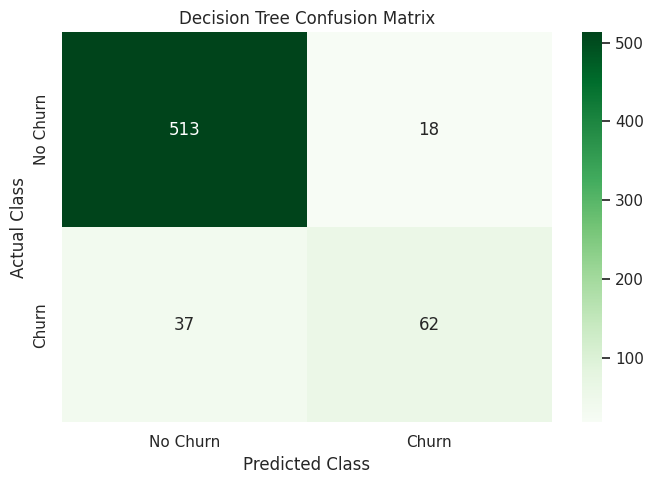

True Negatives : 513
False Positives: 18
False Negatives: 37
True Positives : 62


In [167]:
#Confusion matrix
tree_cm = confusion_matrix(
    y_test,
    y_pred_tree
)

print(tree_cm)

plt.figure(figsize=(7, 5))
sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = tree_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

In [168]:
#Classification report
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)
tree_report = classification_report(
    y_test,
    y_pred_tree,
    target_names=["No Churn", "Churn"],
    output_dict=True,
    zero_division=0
)

tree_report_df = pd.DataFrame(
    tree_report
).transpose()

display(tree_report_df.round(4))

              precision    recall  f1-score   support

    No Churn       0.93      0.97      0.95       531
       Churn       0.78      0.63      0.69        99

    accuracy                           0.91       630
   macro avg       0.85      0.80      0.82       630
weighted avg       0.91      0.91      0.91       630



,precision,recall,f1-score,support
No Churn,0.9327,0.9661,0.9491,531.0000
Churn,0.7750,0.6263,0.6927,99.0000
accuracy,0.9127,0.9127,0.9127,0.9127
macro avg,0.8539,0.7962,0.8209,630.0000
weighted avg,0.9079,0.9127,0.9088,630.0000


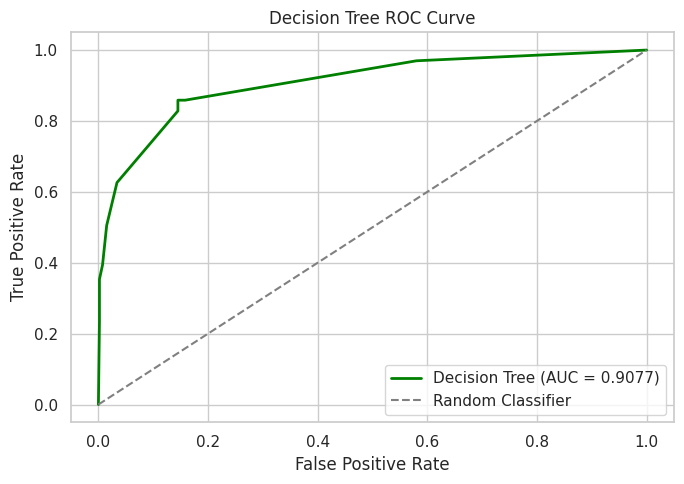

In [169]:
#ROC curve
tree_fpr, tree_tpr, tree_thresholds = roc_curve(
    y_test,
    y_prob_tree
)

plt.figure(figsize=(7, 5))

plt.plot(
    tree_fpr,
    tree_tpr,
    linewidth=2,
    color="green",
    label=f"Decision Tree (AUC = {tree_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

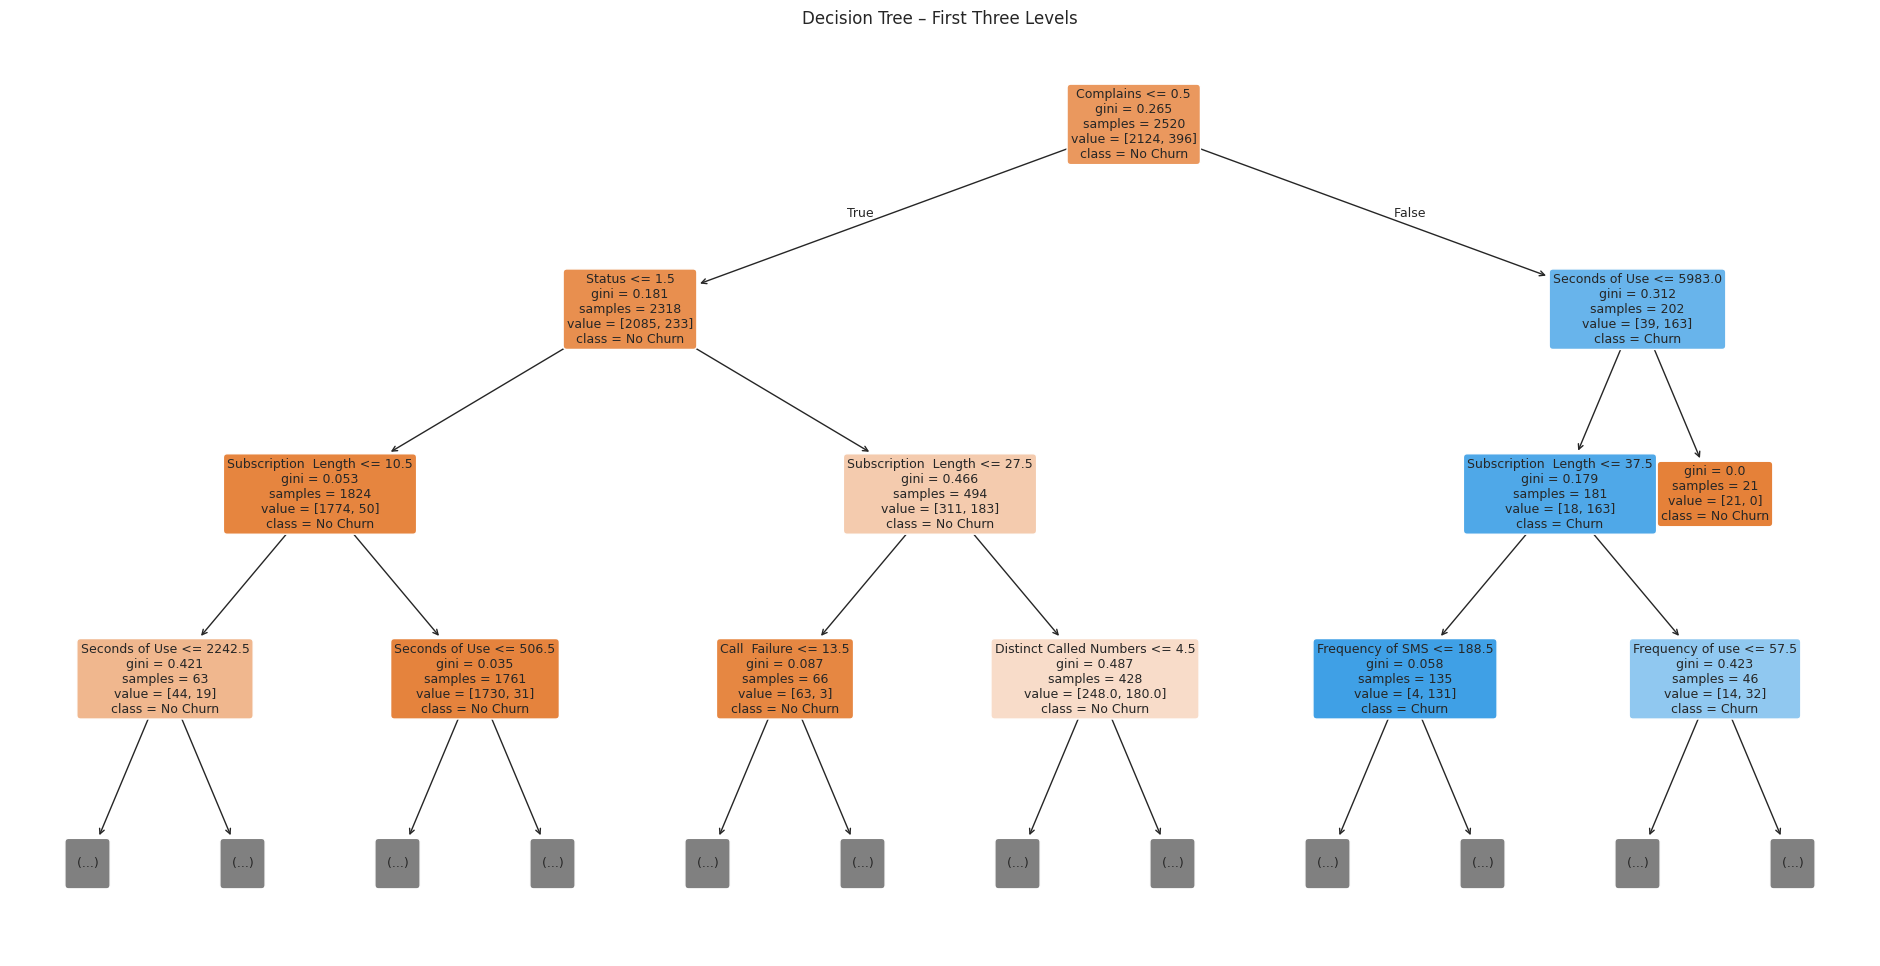

In [170]:
#Visualize the tree
plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree_model,
    feature_names=X_train.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree – First Three Levels")
plt.show()

,Feature,Importance
1,Complains,0.4389
10,Status,0.2165
4,Seconds of Use,0.1386
7,Distinct Called Numbers,0.0855
2,Subscription Length,0.0736
5,Frequency of use,0.0222
11,Age,0.0091
6,Frequency of SMS,0.0082
12,Customer Value,0.0041
0,Call Failure,0.0032


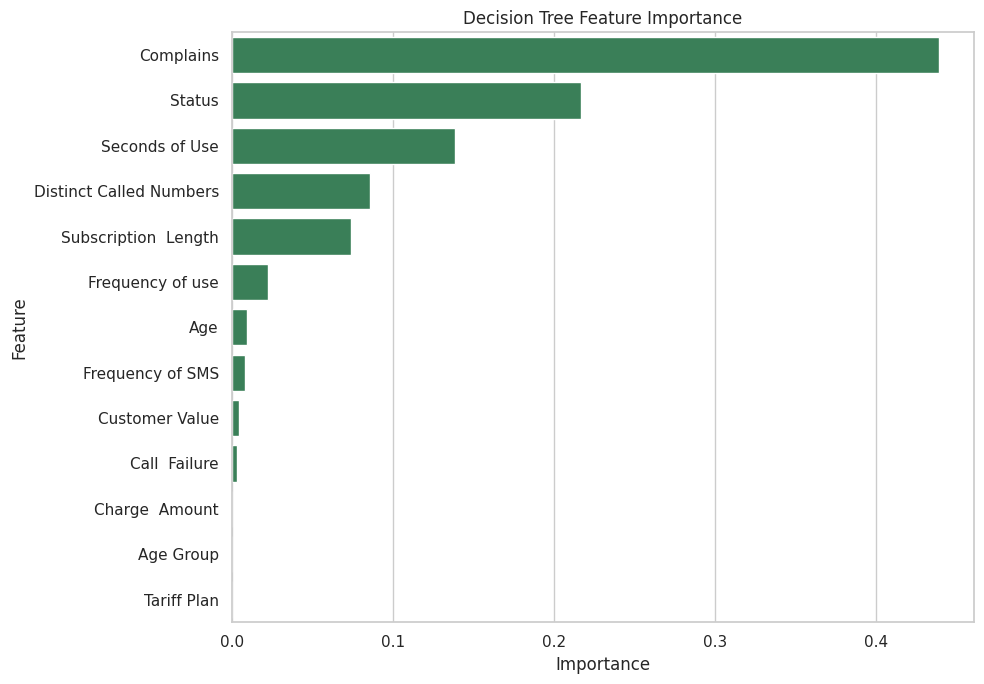

In [171]:
#Feature importance
tree_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": decision_tree_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(tree_feature_importance.round(4))
plt.figure(figsize=(10, 7))

sns.barplot(
    data=tree_feature_importance,
    x="Importance",
    y="Feature",
    color="#2E8B57"
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [172]:
#Compare training and testing accuracy
tree_training_accuracy = decision_tree_model.score(
    X_train,
    y_train
)

tree_testing_accuracy = decision_tree_model.score(
    X_test,
    y_test
)

print(
    f"Training Accuracy: {tree_training_accuracy:.4f}"
)

print(
    f"Testing Accuracy : {tree_testing_accuracy:.4f}"
)

model_comparison = pd.concat(
    [
        logistic_results,
        tree_results
    ],
    ignore_index=True
)

display(model_comparison.round(4))

Training Accuracy: 0.9337
Testing Accuracy : 0.9127


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8968,0.9208,0.840,0.4242,0.5638,0.5509
1,Decision Tree,0.9127,0.9077,0.775,0.6263,0.6927,0.6475


In [173]:
#Save the model
joblib.dump(
    decision_tree_model,
    "model/decision_tree.pkl"
)

print("Decision Tree model saved.")

loaded_tree_model = joblib.load(
    "model/decision_tree.pkl"
)

loaded_tree_predictions = loaded_tree_model.predict(
    X_test
)

print(
    "Saved model predictions match:",
    np.array_equal(
        y_pred_tree,
        loaded_tree_predictions
    )
)

Decision Tree model saved.
Saved model predictions match: True


# K-Nearest Neighbors Classifier

In [174]:
#Create a pipeline
from sklearn.neighbors import KNeighborsClassifier
knn_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        KNeighborsClassifier(
            n_neighbors=5,
            weights="uniform",
            metric="minkowski",
            p=2
        )
    )
])


In [175]:
#Train KNN
knn_pipeline.fit(
    X_train,
    y_train
)

print("KNN training completed.")

KNN training completed.


In [176]:
#Generate predictions
y_pred_knn = knn_pipeline.predict(
    X_test
)

y_prob_knn = knn_pipeline.predict_proba(
    X_test
)[:, 1]
knn_prediction_preview = pd.DataFrame({
    "Actual Churn": y_test.reset_index(drop=True),
    "Predicted Churn": y_pred_knn,
    "Churn Probability": y_prob_knn
})

display(knn_prediction_preview.head(20))

,Actual Churn,Predicted Churn,Churn Probability
0,0,0,0.2
1,0,0,0.0
2,0,0,0.0
3,0,0,0.0
4,0,0,0.0
5,1,0,0.4
6,0,0,0.0
7,0,0,0.0
8,0,0,0.0
9,0,0,0.0


In [177]:
#Calculate all required metrics
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

knn_auc = roc_auc_score(
    y_test,
    y_prob_knn
)

knn_precision = precision_score(
    y_test,
    y_pred_knn,
    zero_division=0
)

knn_recall = recall_score(
    y_test,
    y_pred_knn,
    zero_division=0
)

knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    zero_division=0
)

knn_mcc = matthews_corrcoef(
    y_test,
    y_pred_knn
)
knn_results = pd.DataFrame({
    "ML Model Name": ["K-Nearest Neighbors"],
    "Accuracy": [knn_accuracy],
    "AUC": [knn_auc],
    "Precision": [knn_precision],
    "Recall": [knn_recall],
    "F1": [knn_f1],
    "MCC": [knn_mcc]
})

display(knn_results.round(4))

print(f"Accuracy  : {knn_accuracy:.4f}")
print(f"AUC       : {knn_auc:.4f}")
print(f"Precision : {knn_precision:.4f}")
print(f"Recall    : {knn_recall:.4f}")
print(f"F1 Score  : {knn_f1:.4f}")
print(f"MCC Score : {knn_mcc:.4f}")

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,K-Nearest Neighbors,0.9524,0.9677,0.8632,0.8283,0.8454,0.8175


Accuracy  : 0.9524
AUC       : 0.9677
Precision : 0.8632
Recall    : 0.8283
F1 Score  : 0.8454
MCC Score : 0.8175


[[518  13]
 [ 17  82]]


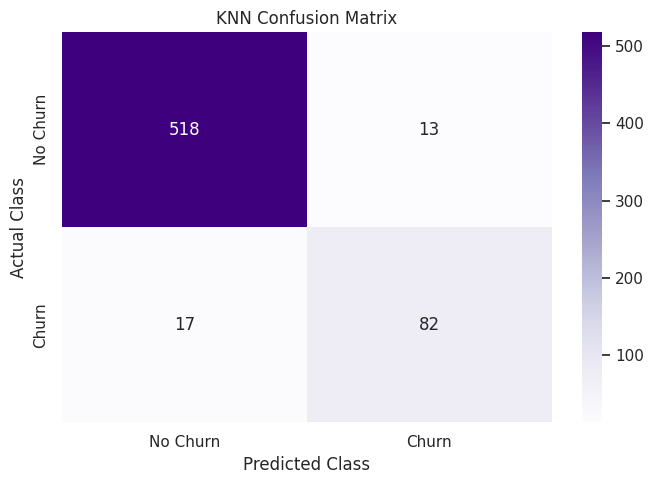

In [178]:
#Confusion matrix
knn_cm = confusion_matrix(
    y_test,
    y_pred_knn
)

print(knn_cm)

plt.figure(figsize=(7, 5))
sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [179]:
#Classification report
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Churn       0.97      0.98      0.97       531
       Churn       0.86      0.83      0.85        99

    accuracy                           0.95       630
   macro avg       0.92      0.90      0.91       630
weighted avg       0.95      0.95      0.95       630



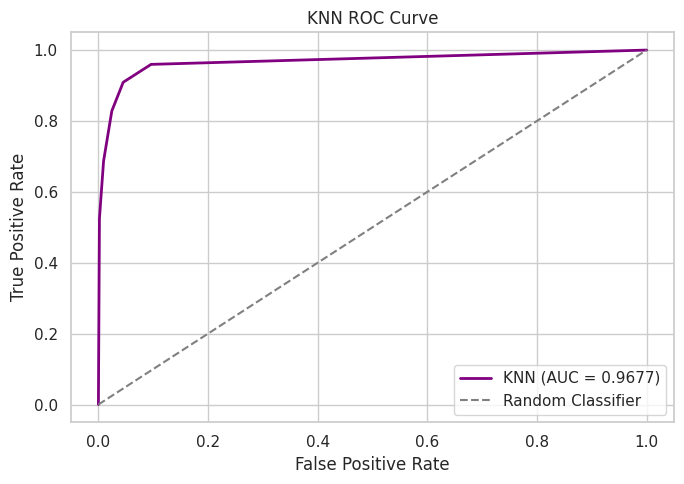

In [180]:
#ROC curve
knn_fpr, knn_tpr, knn_thresholds = roc_curve(
    y_test,
    y_prob_knn
)

plt.figure(figsize=(7, 5))

plt.plot(
    knn_fpr,
    knn_tpr,
    linewidth=2,
    color="purple",
    label=f"KNN (AUC = {knn_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [181]:
#Compare training and testing accuracy
knn_training_accuracy = knn_pipeline.score(
    X_train,
    y_train
)

knn_testing_accuracy = knn_pipeline.score(
    X_test,
    y_test
)

print(
    f"Training Accuracy: {knn_training_accuracy:.4f}"
)

print(
    f"Testing Accuracy : {knn_testing_accuracy:.4f}"
)

Training Accuracy: 0.9647
Testing Accuracy : 0.9524


In [182]:
#Add KNN to the comparison
model_comparison = pd.concat(
    [
        logistic_results,
        tree_results,
        knn_results
    ],
    ignore_index=True
)

display(model_comparison.round(4))

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8968,0.9208,0.8400,0.4242,0.5638,0.5509
1,Decision Tree,0.9127,0.9077,0.7750,0.6263,0.6927,0.6475
2,K-Nearest Neighbors,0.9524,0.9677,0.8632,0.8283,0.8454,0.8175


In [183]:
#Save the KNN pipeline
joblib.dump(
    knn_pipeline,
    "model/knn.pkl"
)

print("KNN pipeline saved.")

KNN pipeline saved.


In [184]:
#Verification
loaded_knn_pipeline = joblib.load(
    "model/knn.pkl"
)

loaded_knn_predictions = loaded_knn_pipeline.predict(
    X_test
)

print(
    "Saved KNN predictions match:",
    np.array_equal(
        y_pred_knn,
        loaded_knn_predictions
    )
)

Saved KNN predictions match: True


# Gaussian Naive Bayes Classifier

In [185]:
#Create the pipeline
from sklearn.naive_bayes import GaussianNB
naive_bayes_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        GaussianNB()
    )
])


In [186]:
#Train the naive_bayes model
naive_bayes_pipeline.fit(
    X_train,
    y_train
)

print("Gaussian Naive Bayes training completed.")

Gaussian Naive Bayes training completed.


In [187]:
#Generate predictions
y_pred_nb = naive_bayes_pipeline.predict(
    X_test
)
y_prob_nb = naive_bayes_pipeline.predict_proba(
    X_test
)[:, 1]
nb_prediction_preview = pd.DataFrame({
    "Actual Churn": y_test.reset_index(drop=True),
    "Predicted Churn": y_pred_nb,
    "Churn Probability": y_prob_nb
})

display(nb_prediction_preview.head(20))

,Actual Churn,Predicted Churn,Churn Probability
0,0,1,9.993142e-01
1,0,0,3.208159e-42
2,0,0,1.504782e-05
3,0,0,3.445016e-19
4,0,0,2.489564e-16
5,1,1,9.994895e-01
6,0,0,5.449186e-05
7,0,0,1.991740e-43
8,0,0,6.308427e-10
9,0,1,9.996152e-01


In [188]:
#Calculate all required metrics
nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

nb_auc = roc_auc_score(
    y_test,
    y_prob_nb
)

nb_precision = precision_score(
    y_test,
    y_pred_nb,
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    y_pred_nb,
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    zero_division=0
)

nb_mcc = matthews_corrcoef(
    y_test,
    y_pred_nb
)

nb_results = pd.DataFrame({
    "ML Model Name": ["Gaussian Naive Bayes"],
    "Accuracy": [nb_accuracy],
    "AUC": [nb_auc],
    "Precision": [nb_precision],
    "Recall": [nb_recall],
    "F1": [nb_f1],
    "MCC": [nb_mcc]
})

display(nb_results.round(4))

print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"AUC       : {nb_auc:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1 Score  : {nb_f1:.4f}")
print(f"MCC Score : {nb_mcc:.4f}")

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Gaussian Naive Bayes,0.7381,0.8986,0.3648,0.899,0.519,0.4536


Accuracy  : 0.7381
AUC       : 0.8986
Precision : 0.3648
Recall    : 0.8990
F1 Score  : 0.5190
MCC Score : 0.4536


[[376 155]
 [ 10  89]]


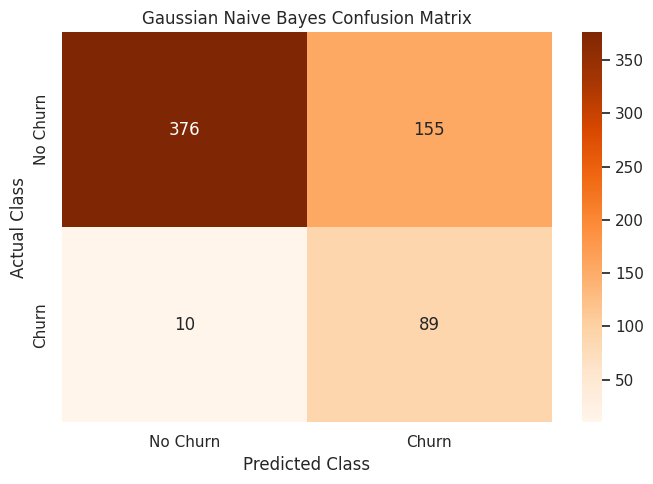

True Negatives : 376
False Positives: 155
False Negatives: 10
True Positives : 89


In [189]:
#Confusion matrix
nb_cm = confusion_matrix(
    y_test,
    y_pred_nb
)

print(nb_cm)

plt.figure(figsize=(7, 5))
sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = nb_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

In [190]:
#Classification report
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

nb_report = classification_report(
    y_test,
    y_pred_nb,
    target_names=["No Churn", "Churn"],
    output_dict=True,
    zero_division=0
)

nb_report_df = pd.DataFrame(
    nb_report
).transpose()

display(nb_report_df.round(4))

              precision    recall  f1-score   support

    No Churn       0.97      0.71      0.82       531
       Churn       0.36      0.90      0.52        99

    accuracy                           0.74       630
   macro avg       0.67      0.80      0.67       630
weighted avg       0.88      0.74      0.77       630



,precision,recall,f1-score,support
No Churn,0.9741,0.7081,0.8201,531.0000
Churn,0.3648,0.8990,0.5190,99.0000
accuracy,0.7381,0.7381,0.7381,0.7381
macro avg,0.6694,0.8035,0.6695,630.0000
weighted avg,0.8783,0.7381,0.7727,630.0000


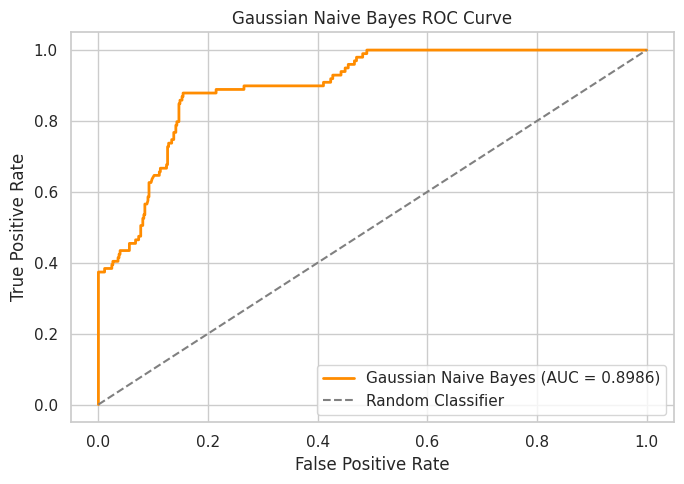

In [191]:
#ROC curve
nb_fpr, nb_tpr, nb_thresholds = roc_curve(
    y_test,
    y_prob_nb
)

plt.figure(figsize=(7, 5))

plt.plot(
    nb_fpr,
    nb_tpr,
    linewidth=2,
    color="darkorange",
    label=f"Gaussian Naive Bayes (AUC = {nb_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gaussian Naive Bayes ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [192]:
#Compare training and testing accuracy
nb_training_accuracy = naive_bayes_pipeline.score(
    X_train,
    y_train
)

nb_testing_accuracy = naive_bayes_pipeline.score(
    X_test,
    y_test
)

print(
    f"Training Accuracy: {nb_training_accuracy:.4f}"
)

print(
    f"Testing Accuracy : {nb_testing_accuracy:.4f}"
)

Training Accuracy: 0.7472
Testing Accuracy : 0.7381


In [193]:
#Examine learned class probabilities
trained_nb_model = (
    naive_bayes_pipeline.named_steps["classifier"]
)
print("Classes:", trained_nb_model.classes_)

class_prior_table = pd.DataFrame({
    "Class": ["No Churn", "Churn"],
    "Prior Probability": trained_nb_model.class_prior_
})
display(class_prior_table.round(4))

Classes: [0 1]


,Class,Prior Probability
0,No Churn,0.8429
1,Churn,0.1571


In [194]:
#Add Naive Bayes to the comparison
model_comparison = pd.concat(
    [
        logistic_results,
        tree_results,
        knn_results,
        nb_results
    ],
    ignore_index=True
)

display(model_comparison.round(4))

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8968,0.9208,0.8400,0.4242,0.5638,0.5509
1,Decision Tree,0.9127,0.9077,0.7750,0.6263,0.6927,0.6475
2,K-Nearest Neighbors,0.9524,0.9677,0.8632,0.8283,0.8454,0.8175
3,Gaussian Naive Bayes,0.7381,0.8986,0.3648,0.8990,0.5190,0.4536


In [195]:
#Save the model pipeline
import os

os.makedirs("model", exist_ok=True)
joblib.dump(
    naive_bayes_pipeline,
    "model/naive_bayes.pkl"
)

print("Gaussian Naive Bayes pipeline saved.")

Gaussian Naive Bayes pipeline saved.


In [196]:
#Verify the saved model
loaded_nb_pipeline = joblib.load(
    "model/naive_bayes.pkl"
)

loaded_nb_predictions = loaded_nb_pipeline.predict(
    X_test
)

print(
    "Saved Naive Bayes predictions match:",
    np.array_equal(
        y_pred_nb,
        loaded_nb_predictions
    )
)

Saved Naive Bayes predictions match: True


# Random Forest Classifier

In [197]:
#Create the model
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    criterion="gini",
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

In [198]:
#Train the model
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [199]:
#Generate predictions
y_pred_rf = random_forest_model.predict(
    X_test
)
y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]
rf_prediction_preview = pd.DataFrame({
    "Actual Churn": y_test.reset_index(drop=True),
    "Predicted Churn": y_pred_rf,
    "Churn Probability": y_prob_rf
})

display(rf_prediction_preview.head(20))

,Actual Churn,Predicted Churn,Churn Probability
0,0,0,0.213259
1,0,0,0.004626
2,0,0,0.011256
3,0,0,0.000000
4,0,0,0.000049
5,1,1,0.577005
6,0,0,0.058505
7,0,0,0.064763
8,0,0,0.000165
9,0,0,0.193222


In [200]:
#Calculate the required metrics
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_mcc = matthews_corrcoef(
    y_test,
    y_pred_rf
)

rf_results = pd.DataFrame({
    "ML Model Name": ["Random Forest"],
    "Accuracy": [rf_accuracy],
    "AUC": [rf_auc],
    "Precision": [rf_precision],
    "Recall": [rf_recall],
    "F1": [rf_f1],
    "MCC": [rf_mcc]
})

display(rf_results.round(4))

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"AUC       : {rf_auc:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"MCC Score : {rf_mcc:.4f}")

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Random Forest,0.9556,0.9875,0.8901,0.8182,0.8526,0.8275


Accuracy  : 0.9556
AUC       : 0.9875
Precision : 0.8901
Recall    : 0.8182
F1 Score  : 0.8526
MCC Score : 0.8275


[[521  10]
 [ 18  81]]


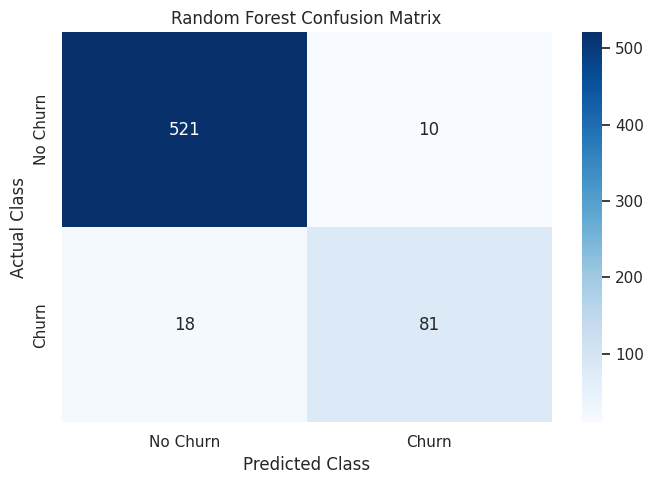

True Negatives : 521
False Positives: 10
False Negatives: 18
True Positives : 81


In [201]:
#Confusion matrix
rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print(rf_cm)

plt.figure(figsize=(7, 5))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = rf_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

In [202]:
#Classification report
rf_report = classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Churn", "Churn"],
    output_dict=True,
    zero_division=0
)

rf_report_df = pd.DataFrame(
    rf_report
).transpose()

display(rf_report_df.round(4))

,precision,recall,f1-score,support
No Churn,0.9666,0.9812,0.9738,531.0000
Churn,0.8901,0.8182,0.8526,99.0000
accuracy,0.9556,0.9556,0.9556,0.9556
macro avg,0.9284,0.8997,0.9132,630.0000
weighted avg,0.9546,0.9556,0.9548,630.0000


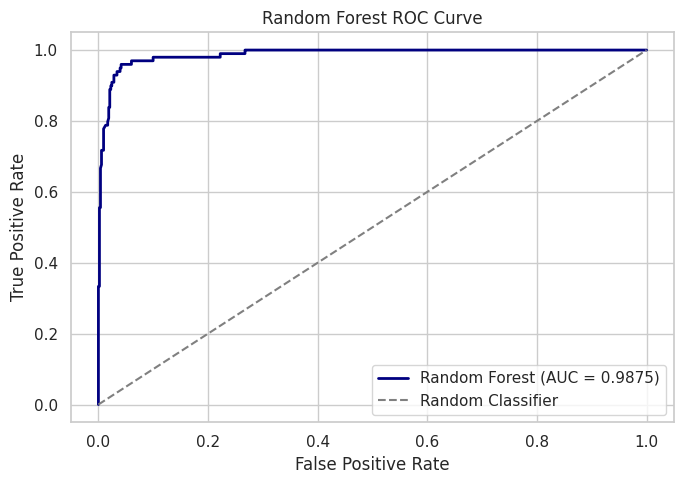

In [203]:
#ROC curve
rf_fpr, rf_tpr, rf_thresholds = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(7, 5))

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    color="navy",
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [204]:
#Compare training and testing accuracy
rf_training_accuracy = random_forest_model.score(
    X_train,
    y_train
)

rf_testing_accuracy = random_forest_model.score(
    X_test,
    y_test
)

print(
    f"Training Accuracy: {rf_training_accuracy:.4f}"
)

print(
    f"Testing Accuracy : {rf_testing_accuracy:.4f}"
)

print(
    f"Accuracy Difference: "
    f"{rf_training_accuracy - rf_testing_accuracy:.4f}"
)

Training Accuracy: 0.9647
Testing Accuracy : 0.9556
Accuracy Difference: 0.0091


,Feature,Importance
1,Complains,0.2404
10,Status,0.1448
4,Seconds of Use,0.1173
5,Frequency of use,0.1077
2,Subscription Length,0.0954
7,Distinct Called Numbers,0.0749
12,Customer Value,0.0686
0,Call Failure,0.0499
6,Frequency of SMS,0.0394
11,Age,0.0239


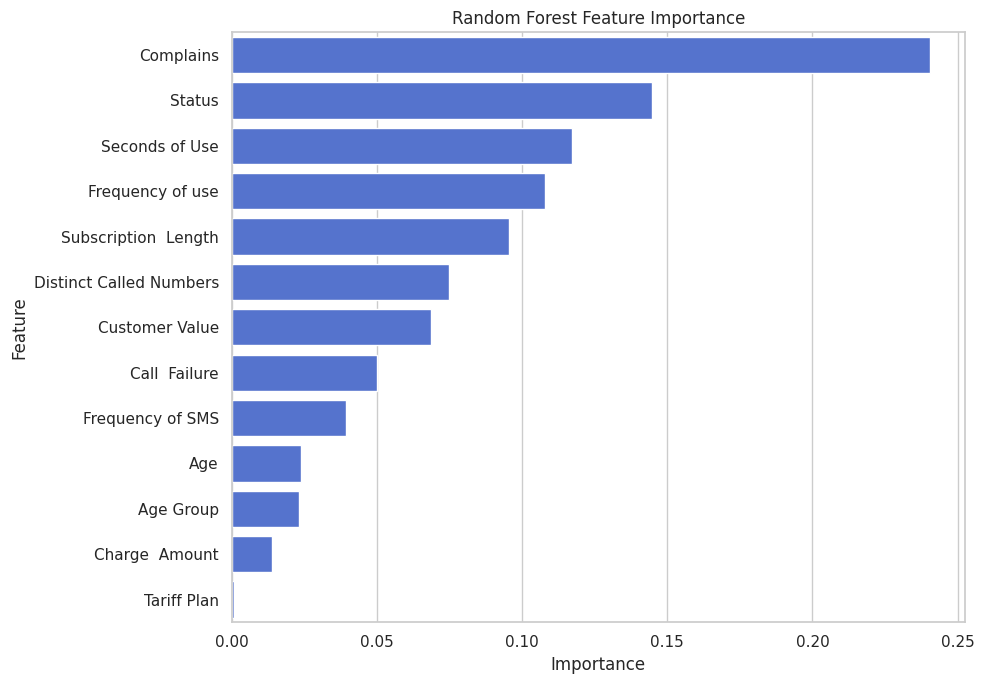

In [205]:
#Random Forest feature importance
rf_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(rf_feature_importance.round(4))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=rf_feature_importance,
    x="Importance",
    y="Feature",
    color="#4169E1"
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [206]:
#Create the complete model-comparison table
model_comparison = pd.concat(
    [
        logistic_results,
        tree_results,
        knn_results,
        nb_results,
        rf_results
    ],
    ignore_index=True
)
display(model_comparison.round(4))




,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8968,0.9208,0.8400,0.4242,0.5638,0.5509
1,Decision Tree,0.9127,0.9077,0.7750,0.6263,0.6927,0.6475
2,K-Nearest Neighbors,0.9524,0.9677,0.8632,0.8283,0.8454,0.8175
3,Gaussian Naive Bayes,0.7381,0.8986,0.3648,0.8990,0.5190,0.4536
4,Random Forest,0.9556,0.9875,0.8901,0.8182,0.8526,0.8275


In [207]:
#Sortingby F1 Score
model_comparison_by_f1 = model_comparison.sort_values(
    by="F1",
    ascending=False
)
display(model_comparison_by_f1.round(4))

#Find the best model for each metric:\
metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]

for metric in metric_columns:
    best_row = model_comparison.loc[
        model_comparison[metric].idxmax()
    ]

    print(
        f"Best {metric}: "
        f"{best_row['ML Model Name']} "
        f"({best_row[metric]:.4f})"
    )


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
4,Random Forest,0.9556,0.9875,0.8901,0.8182,0.8526,0.8275
2,K-Nearest Neighbors,0.9524,0.9677,0.8632,0.8283,0.8454,0.8175
1,Decision Tree,0.9127,0.9077,0.7750,0.6263,0.6927,0.6475
0,Logistic Regression,0.8968,0.9208,0.8400,0.4242,0.5638,0.5509
3,Gaussian Naive Bayes,0.7381,0.8986,0.3648,0.8990,0.5190,0.4536


Best Accuracy: Random Forest (0.9556)
Best AUC: Random Forest (0.9875)
Best Precision: Random Forest (0.8901)
Best Recall: Gaussian Naive Bayes (0.8990)
Best F1: Random Forest (0.8526)
Best MCC: Random Forest (0.8275)


In [208]:
#Save the Random Forest model
import os
import joblib

os.makedirs("model", exist_ok=True)

joblib.dump(
    random_forest_model,
    "model/random_forest.pkl"
)

print("Random Forest model saved.")

Random Forest model saved.


In [209]:
#Verify the saved model
loaded_rf_model = joblib.load(
    "model/random_forest.pkl"
)

loaded_rf_predictions = loaded_rf_model.predict(
    X_test
)

print(
    "Saved Random Forest predictions match:",
    np.array_equal(
        y_pred_rf,
        loaded_rf_predictions
    )
)

Saved Random Forest predictions match: True


In [210]:
#Save the completed comparison table
os.makedirs("results", exist_ok=True)

model_comparison.round(6).to_csv(
    "results/model_metrics.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


#Comparison

In [211]:
#Displaying the final comparison table
model_comparison = pd.concat(
    [
        logistic_results,
        tree_results,
        knn_results,
        nb_results,
        rf_results
    ],
    ignore_index=True
)

display(model_comparison.round(4))

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8968,0.9208,0.8400,0.4242,0.5638,0.5509
1,Decision Tree,0.9127,0.9077,0.7750,0.6263,0.6927,0.6475
2,K-Nearest Neighbors,0.9524,0.9677,0.8632,0.8283,0.8454,0.8175
3,Gaussian Naive Bayes,0.7381,0.8986,0.3648,0.8990,0.5190,0.4536
4,Random Forest,0.9556,0.9875,0.8901,0.8182,0.8526,0.8275


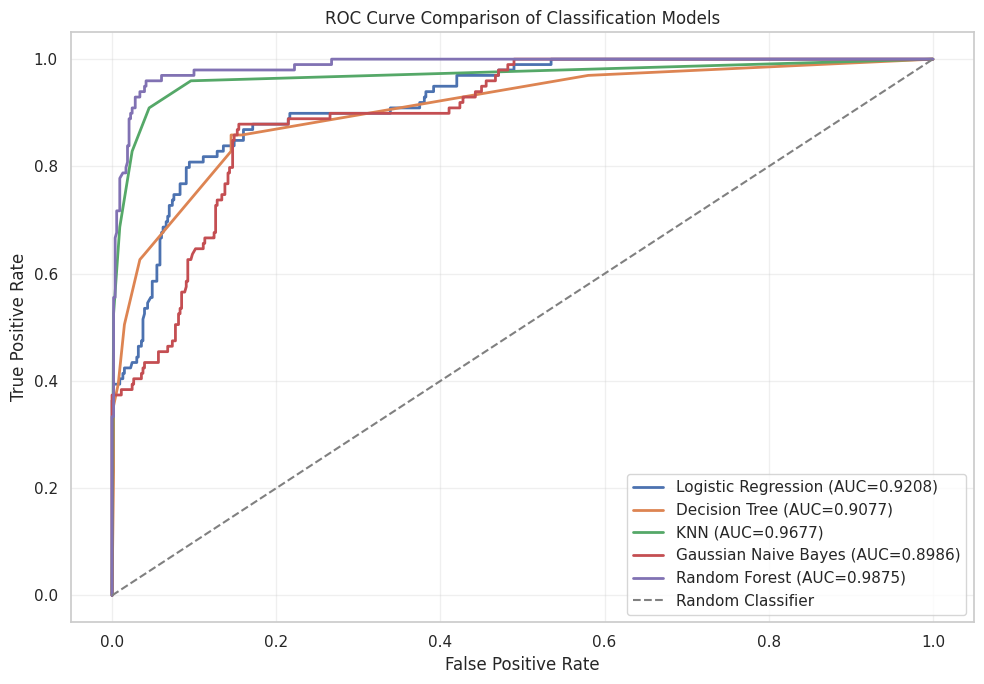

In [212]:
#Creating a combined ROC curve
plt.figure(figsize=(10, 7))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC={logistic_auc:.4f})"
)

plt.plot(
    tree_fpr,
    tree_tpr,
    linewidth=2,
    label=f"Decision Tree (AUC={tree_auc:.4f})"
)

plt.plot(
    knn_fpr,
    knn_tpr,
    linewidth=2,
    label=f"KNN (AUC={knn_auc:.4f})"
)

plt.plot(
    nb_fpr,
    nb_tpr,
    linewidth=2,
    label=f"Gaussian Naive Bayes (AUC={nb_auc:.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f"Random Forest (AUC={rf_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison of Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

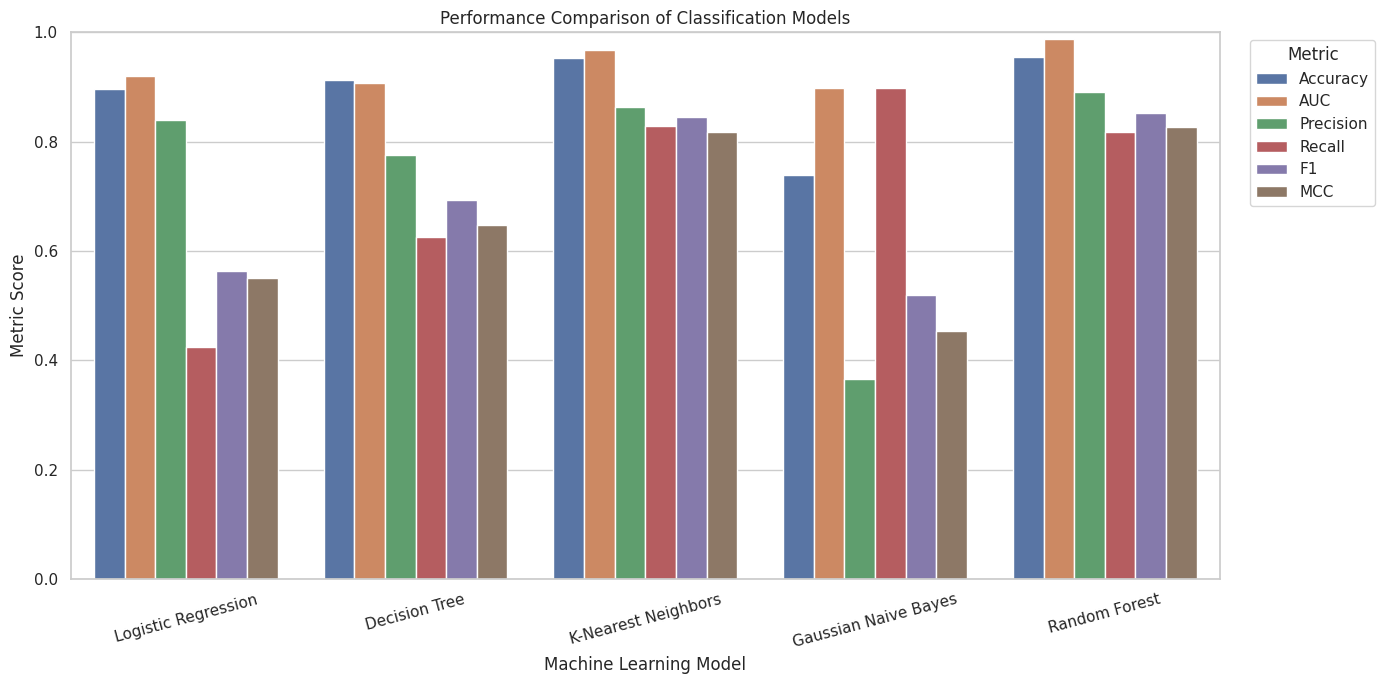

In [213]:
#Creating a metric-comparison graph
comparison_long = model_comparison.melt(
    id_vars="ML Model Name",
    var_name="Metric",
    value_name="Score"
)
plt.figure(figsize=(14, 7))

sns.barplot(
    data=comparison_long,
    x="ML Model Name",
    y="Score",
    hue="Metric"
)

plt.title("Performance Comparison of Classification Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Metric Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [214]:
#Identifying the best model for every metric
metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]

best_models = []

for metric in metric_columns:
    best_index = model_comparison[metric].idxmax()
    best_row = model_comparison.loc[best_index]

    best_models.append({
        "Metric": metric,
        "Best Model": best_row["ML Model Name"],
        "Best Score": best_row[metric]
    })

best_models_df = pd.DataFrame(best_models)

display(best_models_df.round(4))

,Metric,Best Model,Best Score
0,Accuracy,Random Forest,0.9556
1,AUC,Random Forest,0.9875
2,Precision,Random Forest,0.8901
3,Recall,Gaussian Naive Bayes,0.8990
4,F1,Random Forest,0.8526
5,MCC,Random Forest,0.8275


In [215]:
#Determining the overall winner
ranking_metrics = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]

ranked_comparison = model_comparison.copy()

for metric in ranking_metrics:
    ranked_comparison[f"{metric} Rank"] = (
        ranked_comparison[metric]
        .rank(ascending=False, method="min")
    )

rank_columns = [
    f"{metric} Rank"
    for metric in ranking_metrics
]

ranked_comparison["Average Rank"] = (
    ranked_comparison[rank_columns].mean(axis=1)
)

ranked_comparison = ranked_comparison.sort_values(
    by="Average Rank"
)

display(ranked_comparison.round(4))

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC,Accuracy Rank,AUC Rank,Precision Rank,Recall Rank,F1 Rank,MCC Rank,Average Rank
4,Random Forest,0.9556,0.9875,0.8901,0.8182,0.8526,0.8275,1.0,1.0,1.0,3.0,1.0,1.0,1.3333
2,K-Nearest Neighbors,0.9524,0.9677,0.8632,0.8283,0.8454,0.8175,2.0,2.0,2.0,2.0,2.0,2.0,2.0000
1,Decision Tree,0.9127,0.9077,0.7750,0.6263,0.6927,0.6475,3.0,4.0,4.0,4.0,3.0,3.0,3.5000
0,Logistic Regression,0.8968,0.9208,0.8400,0.4242,0.5638,0.5509,4.0,3.0,3.0,5.0,4.0,4.0,3.8333
3,Gaussian Naive Bayes,0.7381,0.8986,0.3648,0.8990,0.5190,0.4536,5.0,5.0,5.0,1.0,5.0,5.0,4.3333


In [216]:
#Creating the required observation table
model_observations = pd.DataFrame({
    "ML Model Name": [
        "Logistic Regression",
        "Decision Tree",
        "K-Nearest Neighbors",
        "Gaussian Naive Bayes",
        "Random Forest",
        "Overall Winner"
    ],

    "Observation about model performance": [
        (
            "Logistic Regression achieved an accuracy of 0.8968 and "
            "an AUC of 0.9208. Its precision was high at 0.8400, "
            "indicating that most customers predicted as churners "
            "actually churned. However, its recall was only 0.4242, "
            "meaning that it failed to identify a considerable number "
            "of actual churn customers."
        ),

        (
            "The Decision Tree achieved an accuracy of 0.9127 and "
            "an AUC of 0.9077. It provided a better balance between "
            "precision and recall than Logistic Regression, with an "
            "F1 score of 0.6927. However, its overall performance was "
            "lower than KNN and Random Forest."
        ),

        (
            "K-Nearest Neighbors achieved an accuracy of 0.9524 and "
            "an AUC of 0.9677. It produced strong precision, recall, "
            "F1 and MCC scores. Its recall of 0.8283 was slightly "
            "higher than Random Forest, making it effective at "
            "identifying actual churn customers."
        ),

        (
            "Gaussian Naive Bayes achieved the highest recall of "
            "0.8990, meaning that it identified approximately 89.90% "
            "of actual churn customers. However, its precision was "
            "only 0.3648 and its accuracy was 0.7381, indicating that "
            "it incorrectly classified many non-churn customers as "
            "churners. Its performance may have been affected by the "
            "strong correlations among several input features."
        ),

        (
            "Random Forest achieved the highest accuracy of 0.9556, "
            "AUC of 0.9875, precision of 0.8901, F1 score of 0.8526 "
            "and MCC of 0.8275. It provided the most consistent and "
            "well-balanced performance across the evaluation metrics, "
            "although its recall was slightly lower than KNN and "
            "Gaussian Naive Bayes."
        ),

        (
            "Random Forest was selected as the overall winner because "
            "it achieved the best Accuracy, AUC, Precision, F1 and MCC "
            "scores, with the lowest average rank of 1.3333. Although "
            "Gaussian Naive Bayes achieved the highest recall and KNN "
            "achieved slightly better recall than Random Forest, Random "
            "Forest provided the best overall balance between correctly "
            "detecting churn customers and avoiding incorrect churn "
            "predictions."
        )
    ]
})

display(model_observations)

,ML Model Name,Observation about model performance
0,Logistic Regression,Logistic Regression achieved an accuracy of 0....
1,Decision Tree,The Decision Tree achieved an accuracy of 0.91...
2,K-Nearest Neighbors,K-Nearest Neighbors achieved an accuracy of 0....
3,Gaussian Naive Bayes,Gaussian Naive Bayes achieved the highest reca...
4,Random Forest,Random Forest achieved the highest accuracy of...
5,Overall Winner,Random Forest was selected as the overall winn...


In [217]:
#Save final results
model_comparison.round(6).to_csv(
    "results/model_metrics.csv",
    index=False
)

best_models_df.round(6).to_csv(
    "results/best_models_by_metric.csv",
    index=False
)

ranked_comparison.round(6).to_csv(
    "results/model_ranking.csv",
    index=False
)

print("Final comparison results saved successfully.")

Final comparison results saved successfully.


In [218]:
test_data = X_test.copy()
test_data["Churn"] = y_test

test_data.to_csv(
    "test_data.csv",
    index=False
)

print("Test data shape:", test_data.shape)
display(test_data.head())

Test data shape: (630, 14)


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
3036,2,0,36,0,1260,39,20,22,3,1,2,30,131.960,0
1783,18,0,29,2,15580,231,0,75,2,1,1,25,711.495,0
2539,7,0,25,1,1693,37,26,65,5,1,1,55,64.950,0
1807,6,0,30,0,8810,109,129,40,3,1,1,30,872.760,0
3020,6,0,38,1,11060,149,0,49,4,1,1,45,280.225,0


In [219]:
print(test_data.columns.tolist())

['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value', 'Churn']


In [220]:
import os

required_model_files = [
    "model/logistic_regression.pkl",
    "model/decision_tree.pkl",
    "model/knn.pkl",
    "model/naive_bayes.pkl",
    "model/random_forest.pkl"
]

for file_path in required_model_files:
    print(
        file_path,
        "✅ Available" if os.path.exists(file_path) else "❌ Missing"
    )

print(
    "test_data.csv",
    "✅ Available" if os.path.exists("test_data.csv") else "❌ Missing"
)

print(
    "results/model_metrics.csv",
    "✅ Available"
    if os.path.exists("results/model_metrics.csv")
    else "❌ Missing"
)

model/logistic_regression.pkl ✅ Available
model/decision_tree.pkl ✅ Available
model/knn.pkl ✅ Available
model/naive_bayes.pkl ✅ Available
model/random_forest.pkl ✅ Available
test_data.csv ✅ Available
results/model_metrics.csv ✅ Available


In [221]:
#Creating app.py
import os
import joblib
import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)


# ---------------------------------------------------------
# Page configuration
# ---------------------------------------------------------

st.set_page_config(
    page_title="Telecom Churn Analytics",
    page_icon="📡",
    layout="wide"
)


# ---------------------------------------------------------
# Custom styling
# ---------------------------------------------------------

st.markdown(
    """
    <style>
        .main-title {
            color: #123B5D;
            font-size: 2.4rem;
            font-weight: 750;
            margin-bottom: 0;
        }

        .subtitle {
            color: #526777;
            font-size: 1.05rem;
            margin-bottom: 1.5rem;
        }

        .section-title {
            color: #123B5D;
            font-size: 1.35rem;
            font-weight: 700;
            margin-top: 1rem;
        }

        [data-testid="stMetric"] {
            background-color: #F3F8FC;
            border: 1px solid #D7E6F2;
            border-radius: 10px;
            padding: 15px;
        }
    </style>
    """,
    unsafe_allow_html=True
)


# ---------------------------------------------------------
# Application header
# ---------------------------------------------------------

st.markdown(
    '<p class="main-title">📡 Telecom Customer Churn Analytics</p>',
    unsafe_allow_html=True
)

st.markdown(
    """
    <p class="subtitle">
        Evaluate trained classification models using uploaded telecom
        customer test data.
    </p>
    """,
    unsafe_allow_html=True
)


# ---------------------------------------------------------
# Model configuration
# ---------------------------------------------------------

MODEL_FILES = {
    "Logistic Regression": "model/logistic_regression.pkl",
    "Decision Tree": "model/decision_tree.pkl",
    "K-Nearest Neighbors": "model/knn.pkl",
    "Gaussian Naive Bayes": "model/naive_bayes.pkl",
    "Random Forest": "model/random_forest.pkl"
}


@st.cache_resource
def load_model(model_path):
    return joblib.load(model_path)


@st.cache_data
def load_comparison_results():
    results_path = "results/model_metrics.csv"

    if os.path.exists(results_path):
        return pd.read_csv(results_path)

    return None


# ---------------------------------------------------------
# Sidebar
# ---------------------------------------------------------

with st.sidebar:
    st.header("Model Controls")

    selected_model_name = st.selectbox(
        "Select a classification model",
        options=list(MODEL_FILES.keys())
    )

    st.info(
        "The uploaded CSV must contain the original input features "
        "and the actual `Churn` column."
    )

    st.markdown("---")

    st.markdown(
        """
        **Target definition**

        - `0` — No Churn
        - `1` — Churn
        """
    )


# ---------------------------------------------------------
# Dataset uploader
# ---------------------------------------------------------

st.markdown(
    '<p class="section-title">Upload Test Dataset</p>',
    unsafe_allow_html=True
)

uploaded_file = st.file_uploader(
    "Upload the test data in CSV format",
    type=["csv"]
)


# ---------------------------------------------------------
# Model comparison
# ---------------------------------------------------------

comparison_results = load_comparison_results()

if comparison_results is not None:
    with st.expander(
        "View precomputed model comparison",
        expanded=False
    ):
        st.dataframe(
            comparison_results.round(4),
            use_container_width=True,
            hide_index=True
        )

        if "F1" in comparison_results.columns:
            best_model_row = comparison_results.loc[
                comparison_results["F1"].idxmax()
            ]

            st.success(
                "Best model based on F1 score: "
                f"{best_model_row['ML Model Name']} "
                f"({best_model_row['F1']:.4f})"
            )


# ---------------------------------------------------------
# Uploaded-data processing
# ---------------------------------------------------------

if uploaded_file is None:
    st.info(
        "Upload `test_data.csv` to begin model evaluation."
    )

else:
    try:
        test_data = pd.read_csv(uploaded_file)

        st.success(
            f"Dataset uploaded successfully: "
            f"{test_data.shape[0]} rows and "
            f"{test_data.shape[1]} columns."
        )

        with st.expander(
            "Preview uploaded test data",
            expanded=True
        ):
            st.dataframe(
                test_data.head(20),
                use_container_width=True
            )

        if "Churn" not in test_data.columns:
            st.error(
                "The uploaded file does not contain the required "
                "`Churn` target column."
            )

            st.stop()

        if test_data.empty:
            st.error(
                "The uploaded CSV does not contain any records."
            )

            st.stop()

        model_path = MODEL_FILES[selected_model_name]

        if not os.path.exists(model_path):
            st.error(
                f"Model file is missing: `{model_path}`"
            )

            st.stop()

        selected_model = load_model(model_path)

        if hasattr(selected_model, "feature_names_in_"):
            expected_features = list(
                selected_model.feature_names_in_
            )
        else:
            expected_features = [
                column
                for column in test_data.columns
                if column != "Churn"
            ]

        uploaded_features = [
            column
            for column in test_data.columns
            if column != "Churn"
        ]

        missing_features = [
            feature
            for feature in expected_features
            if feature not in uploaded_features
        ]

        extra_features = [
            feature
            for feature in uploaded_features
            if feature not in expected_features
        ]

        if missing_features:
            st.error(
                "Required feature columns are missing: "
                + ", ".join(missing_features)
            )

            st.stop()

        if extra_features:
            st.warning(
                "Extra columns were ignored: "
                + ", ".join(extra_features)
            )

        X_uploaded = test_data[expected_features].copy()
        y_uploaded = test_data["Churn"].copy()

        if X_uploaded.isnull().any().any():
            st.error(
                "The uploaded input features contain missing values."
            )

            st.stop()

        if y_uploaded.isnull().any():
            st.error(
                "The `Churn` column contains missing values."
            )

            st.stop()

        invalid_targets = set(
            y_uploaded.unique()
        ) - {0, 1}

        if invalid_targets:
            st.error(
                "The `Churn` column must contain only 0 and 1. "
                f"Invalid values found: {invalid_targets}"
            )

            st.stop()

        non_numeric_columns = (
            X_uploaded
            .select_dtypes(exclude=np.number)
            .columns
            .tolist()
        )

        if non_numeric_columns:
            st.error(
                "The following features must be numeric: "
                + ", ".join(non_numeric_columns)
            )

            st.stop()

        st.markdown(
            '<p class="section-title">Model Evaluation</p>',
            unsafe_allow_html=True
        )

        st.write(
            f"Selected model: **{selected_model_name}**"
        )

        if st.button(
            "Evaluate Selected Model",
            type="primary",
            use_container_width=True
        ):
            y_prediction = selected_model.predict(
                X_uploaded
            )

            y_probability = selected_model.predict_proba(
                X_uploaded
            )[:, 1]

            accuracy = accuracy_score(
                y_uploaded,
                y_prediction
            )

            auc = roc_auc_score(
                y_uploaded,
                y_probability
            )

            precision = precision_score(
                y_uploaded,
                y_prediction,
                zero_division=0
            )

            recall = recall_score(
                y_uploaded,
                y_prediction,
                zero_division=0
            )

            f1 = f1_score(
                y_uploaded,
                y_prediction,
                zero_division=0
            )

            mcc = matthews_corrcoef(
                y_uploaded,
                y_prediction
            )

            metric_columns = st.columns(6)

            metric_columns[0].metric(
                "Accuracy",
                f"{accuracy:.4f}"
            )

            metric_columns[1].metric(
                "AUC",
                f"{auc:.4f}"
            )

            metric_columns[2].metric(
                "Precision",
                f"{precision:.4f}"
            )

            metric_columns[3].metric(
                "Recall",
                f"{recall:.4f}"
            )

            metric_columns[4].metric(
                "F1 Score",
                f"{f1:.4f}"
            )

            metric_columns[5].metric(
                "MCC",
                f"{mcc:.4f}"
            )

            left_column, right_column = st.columns(2)

            with left_column:
                st.subheader("Confusion Matrix")

                cm = confusion_matrix(
                    y_uploaded,
                    y_prediction,
                    labels=[0, 1]
                )

                figure, axis = plt.subplots(
                    figsize=(6, 4)
                )

                sns.heatmap(
                    cm,
                    annot=True,
                    fmt="d",
                    cmap="Blues",
                    xticklabels=[
                        "No Churn",
                        "Churn"
                    ],
                    yticklabels=[
                        "No Churn",
                        "Churn"
                    ],
                    ax=axis
                )

                axis.set_xlabel("Predicted Class")
                axis.set_ylabel("Actual Class")
                axis.set_title(
                    f"{selected_model_name} Confusion Matrix"
                )

                figure.tight_layout()

                st.pyplot(figure)

                plt.close(figure)

            with right_column:
                st.subheader("Classification Report")

                report = classification_report(
                    y_uploaded,
                    y_prediction,
                    target_names=[
                        "No Churn",
                        "Churn"
                    ],
                    output_dict=True,
                    zero_division=0
                )

                report_dataframe = (
                    pd.DataFrame(report)
                    .transpose()
                    .round(4)
                )

                st.dataframe(
                    report_dataframe,
                    use_container_width=True
                )

            prediction_results = test_data.copy()

            prediction_results[
                "Predicted Churn"
            ] = y_prediction

            prediction_results[
                "Churn Probability"
            ] = y_probability.round(4)

            st.subheader("Prediction Results")

            st.dataframe(
                prediction_results,
                use_container_width=True
            )

            prediction_csv = (
                prediction_results
                .to_csv(index=False)
                .encode("utf-8")
            )

            st.download_button(
                label="Download Prediction Results",
                data=prediction_csv,
                file_name=(
                    "telecom_churn_predictions.csv"
                ),
                mime="text/csv"
            )

    except pd.errors.EmptyDataError:
        st.error(
            "The uploaded CSV file is empty or invalid."
        )

    except Exception as error:
        st.error(
            "The application could not process the uploaded file."
        )

        st.exception(error)

2026-08-18 02:37:24.673 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 02:37:24.675 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 02:37:25.197 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-08-18 02:37:25.201 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 02:37:25.204 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 02:37:25.208 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 02:37:25.211 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [222]:
!pip install -q streamlit